## Importing libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd()

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
CLEANED_DIR = OUTPUT_DIR / "cleaned_data"

for folder in [TABLE_DIR, PLOT_DIR, CLEANED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

## Loading the data

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv(DATA_DIR / "store.csv")

print("Train shape:", train.shape)
print("Store shape:", store.shape)

Train shape: (1017209, 9)
Store shape: (1115, 10)


In [4]:
train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [5]:
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## Dataset Overview

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


In [7]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [8]:
dataset_summary = pd.DataFrame({
    "Dataset": ["train.csv", "store.csv"],
    "Rows": [train.shape[0], store.shape[0]],
    "Columns": [train.shape[1], store.shape[1]],
    "Purpose": [
        "Daily store-level sales, customers, promotions and holiday data",
        "Store characteristics, competition information and Promo2 participation"
    ]
})

dataset_summary

,Dataset,Rows,Columns,Purpose
0,train.csv,1017209,9,"Daily store-level sales, customers, promotions..."
1,store.csv,1115,10,"Store characteristics, competition information..."


In [9]:
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)

## Data quality

In [10]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in store:", store.duplicated().sum())
print("Duplicate Store IDs:", store["Store"].duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in store: 0
Duplicate Store IDs: 0


### Duplicate Records

No complete duplicate records were found in either `train.csv` or `store.csv`. Therefore, no duplicate-removal procedure was required.

The absence of duplicate store records in `store.csv` also supports the validity of the many-to-one merge between the daily sales data and the store-characteristics data.

In [11]:
train_missing = (train.isna().sum().reset_index())

train_missing.columns = ["Variable", "MissingValues"]

store_missing = (store.isna().sum().reset_index())

store_missing.columns = ["Variable", "MissingValues"]

display(train_missing)
display(store_missing)

,Variable,MissingValues
0,Store,0
1,DayOfWeek,0
2,Date,0
3,Sales,0
4,Customers,0
5,Open,0
6,Promo,0
7,StateHoliday,0
8,SchoolHoliday,0


,Variable,MissingValues
0,Store,0
1,StoreType,0
2,Assortment,0
3,CompetitionDistance,3
4,CompetitionOpenSinceMonth,354
5,CompetitionOpenSinceYear,354
6,Promo2,0
7,Promo2SinceWeek,544
8,Promo2SinceYear,544
9,PromoInterval,544


### Missing-Value Assessment

The daily historical sales variables did not require missing-value imputation. Missing information was concentrated in the store-level competition and Promo2 variables.

`CompetitionDistance` was unavailable for only three stores. The month and year in which the nearest competitor opened were unavailable for 354 stores. These missing competition-opening fields will not be imputed because replacing them with averages would create artificial information.

The Promo2 timing fields contained 544 missing values. These correspond to stores that do not participate in Promo2 and are therefore treated as structurally missing or not applicable rather than as ordinary data-quality errors.

In [12]:
train_missing.to_csv(TABLE_DIR / "train_missing_values.csv", index=False)

store_missing.to_csv(TABLE_DIR / "store_missing_values.csv", index=False)

In [13]:
print("Earliest date:", train["Date"].min())
print("Latest date:", train["Date"].max())
print("Number of stores in train:", train["Store"].nunique())
print("Number of stores in store.csv:", store["Store"].nunique())

Earliest date: 2013-01-01 00:00:00
Latest date: 2015-07-31 00:00:00
Number of stores in train: 1115
Number of stores in store.csv: 1115


In [14]:
train_stores = set(train["Store"].unique())
store_stores = set(store["Store"].unique())

print("Stores missing from store.csv:", train_stores - store_stores)
print("Unused stores in store.csv:", store_stores - train_stores)

Stores missing from store.csv: set()
Unused stores in store.csv: set()


## Merging the datasets

In [15]:
df = train.merge(store, on="Store", how="left", validate="many_to_one")

print("Merged shape:", df.shape)

Merged shape: (1017209, 18)


In [16]:
print("Rows without matching StoreType:", df["StoreType"].isna().sum())

Rows without matching StoreType: 0


### Dataset Overview

The historical sales dataset contains 1,017,209 daily store-level observations and 9 variables, while the store-information dataset contains one record for each of the 1,115 Rossmann stores and 10 variables.

After merging the two datasets using the `Store` identifier, the number of rows remained unchanged at 1,017,209. This confirms that the merge preserved all historical daily observations. The merged dataset contained 19 columns before feature engineering.

After excluding closed-store days and unusual open-day records with zero sales or zero customers, 844,338 normal operating observations remained for the main analysis.

### Merge Validation

The historical sales data was merged with the store-information data using a left join on the `Store` identifier. The merge was defined as a many-to-one relationship because each store appears repeatedly in the daily sales data but only once in the store-information file.

The number of rows after merging was equal to the number of rows in the original historical dataset. This indicates that no daily observations were lost during the merge. The store-level variables were therefore successfully added to the daily performance records.

## Handling closed and unusual store days

In [17]:
# Data quality flag

conditions = [
    df["Open"].eq(0),
    df["Open"].eq(1) & df["Sales"].eq(0),
    df["Open"].eq(1) & df["Customers"].eq(0)
]

labels = ["Closed", "Open but zero sales", "Open but zero customers"]

df["DataIssueFlag"] = np.select(conditions, labels, default="Normal")

In [18]:
data_issue_summary = (df["DataIssueFlag"].value_counts().rename_axis("DataStatus").reset_index(name="Records"))

data_issue_summary

,DataStatus,Records
0,Normal,844338
1,Closed,172817
2,Open but zero sales,54


### Store-Opening and Data-Quality Assessment

Of the 1,017,209 historical observations, 844,338 were classified as normal operating records and 172,817 represented days on which stores were closed.

A further 54 records showed stores marked as open but reporting zero sales. Of these, 52 also recorded zero customers. These observations may represent reporting irregularities or exceptional operating circumstances.

Closed-store observations and unusual open-day records were excluded from the main performance analysis because including them would reduce average sales and customer values and could create misleading comparisons between stores.

In [19]:
data_issue_summary.to_csv(TABLE_DIR / "data_issue_summary.csv", index=False)

In [20]:
open_df = df[(df["Open"] == 1) & (df["Sales"] > 0) & (df["Customers"] > 0)].copy()

print("Operating records:", open_df.shape)

Operating records: (844338, 19)


### Analytical Dataset

The main analytical dataset, `open_df`, was created by retaining observations where:

- the store was marked as open;
- daily sales were greater than zero; and
- the number of customers was greater than zero.

This produced 844,338 valid operating-day observations. The original merged dataset was retained separately so that excluded records could still be documented and examined.

Using a separate analytical dataset ensures that comparisons of average sales, customer footfall and sales per customer reflect actual operating activity rather than store closures or zero-activity records.

#### We will use:

- #### df for overall data-quality and closure analysis
- #### open_df for sales, customers and promotion comparisons

## Creating New Variables

In [21]:
# Date variables

open_df["Year"] = open_df["Date"].dt.year
open_df["MonthNumber"] = open_df["Date"].dt.month
open_df["MonthName"] = open_df["Date"].dt.month_name()
open_df["Quarter"] = open_df["Date"].dt.to_period("Q").astype(str)
open_df["YearMonth"] = open_df["Date"].dt.to_period("M").astype(str)
open_df["WeekOfYear"] = open_df["Date"].dt.isocalendar().week.astype(int)

In [22]:
# Weekday names

day_mapping = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

open_df["WeekdayName"] = open_df["DayOfWeek"].map(day_mapping)

open_df["WeekendFlag"] = np.where(
    open_df["DayOfWeek"].isin([6, 7]),
    "Weekend",
    "Weekday"
)

In [23]:
# Making the labels readable

store_type_mapping = {
    "a": "Type A",
    "b": "Type B",
    "c": "Type C",
    "d": "Type D"
}

assortment_mapping = {
    "a": "Basic",
    "b": "Extra",
    "c": "Extended"
}

state_holiday_mapping = {
    "0": "No State Holiday",
    "a": "Public Holiday",
    "b": "Easter Holiday",
    "c": "Christmas Holiday"
}

open_df["StoreTypeLabel"] = open_df["StoreType"].map(store_type_mapping)
open_df["AssortmentLabel"] = open_df["Assortment"].map(assortment_mapping)
open_df["StateHolidayLabel"] = (open_df["StateHoliday"].astype(str).map(state_holiday_mapping))

open_df["SchoolHolidayLabel"] = open_df["SchoolHoliday"].map({0: "No School Holiday", 1: "School Holiday"})

open_df["PromoLabel"] = open_df["Promo"].map({0: "No Promotion", 1: "Promotion"})

open_df["Promo2Label"] = open_df["Promo2"].map({0: "Not Participating", 1: "Participating"})

In [24]:
# Sales per customer

open_df["SalesPerCustomer"] = (open_df["Sales"] / open_df["Customers"])

### Creating new variables

Additional variables were created to support business interpretation. Date-related fields such as year, month, quarter, week and weekday were extracted from the original date variable to enable temporal analysis.

Categorical codes for store type, assortment, holidays and promotions were converted into descriptive labels to improve readability in tables and charts.

`SalesPerCustomer` was calculated by dividing daily sales by the number of customers. This measure provides an approximate indication of average turnover per customer and helps separate the effect of customer traffic from customer spending behaviour.


### Preliminary Analytical Limitation

The dataset records turnover but does not include product costs, operating expenses or profit. Therefore, the project evaluates sales performance rather than profitability.

Similarly, comparisons between promotional and non-promotional periods will identify associations and average differences. They should not be interpreted as definitive proof that promotions caused the observed changes, because other store and time-related factors may also influence sales.

In [39]:
open_df[ [ "Sales", "Customers", "SalesPerCustomer", "CompetitionDistance" ] ].describe()

,Sales,Customers,SalesPerCustomer,CompetitionDistance
count,844338.000000,844338.000000,844338.000000,842152.000000
mean,6955.959134,762.777166,9.493641,5458.156627
std,3103.815515,401.194153,2.197448,7809.573181
min,46.000000,8.000000,2.749075,20.000000
25%,4859.000000,519.000000,7.895571,710.000000
50%,6369.000000,676.000000,9.250000,2320.000000
75%,8360.000000,893.000000,10.899729,6890.000000
max,41551.000000,7388.000000,64.957854,75860.000000


### Preliminary Descriptive Insights

Across the 844,338 valid operating observations, average daily sales were approximately 6,955.96, while median daily sales were 6,369. The mean exceeding the median suggests that the sales distribution is positively skewed, with some high-sales observations increasing the overall average.

The average number of customers per operating day was approximately 762.78, compared with a median of 676 customers. The same mean–median pattern indicates that a smaller number of high-footfall observations may be pulling the average upward.

Average sales per customer were approximately 9.49, with a median of 9.25. This measure will help determine whether differences in store sales are primarily associated with customer footfall, spending per customer, or a combination of both.

## Competition-distance bands

#### Because CompetitionDistance is strongly right-skewed, we should create the bands using quartiles from the unique stores, not from all daily observations.

#### That avoids stores with more recorded days influencing the cut-off points.

#### Store-level quartiles

In [40]:
competition_store_values = (store["CompetitionDistance"].dropna())

competition_quartiles = competition_store_values.quantile([0.25, 0.50, 0.75])

competition_quartiles

0.25     717.5
0.50    2325.0
0.75    6882.5
Name: CompetitionDistance, dtype: float64

In [41]:
q1 = competition_store_values.quantile(0.25)
q2 = competition_store_values.quantile(0.50)
q3 = competition_store_values.quantile(0.75)

print(f"Q1: {q1:.0f} metres")
print(f"Median: {q2:.0f} metres")
print(f"Q3: {q3:.0f} metres")

Q1: 718 metres
Median: 2325 metres
Q3: 6882 metres


In [42]:
# Competition-distance bands

competition_bins = [-np.inf, q1, q2, q3, np.inf]

competition_labels = ["Very Close", "Close", "Moderate", "Far"]

open_df["CompetitionDistanceBand"] = pd.cut(
    open_df["CompetitionDistance"],
    bins=competition_bins,
    labels=competition_labels,
    include_lowest=True
)

In [44]:
open_df["CompetitionDistanceBand"] = (open_df["CompetitionDistanceBand"].astype("object").fillna("Unknown"))

In [45]:
# Number of unique stores in each band

store_competition_bands = (open_df[["Store", "CompetitionDistance", "CompetitionDistanceBand"]].drop_duplicates(subset="Store"))

store_band_counts = (store_competition_bands["CompetitionDistanceBand"].value_counts().rename_axis("CompetitionDistanceBand").reset_index(name="NumberOfStores"))

store_band_counts

,CompetitionDistanceBand,NumberOfStores
0,Close,278
1,Very Close,278
2,Far,278
3,Moderate,278
4,Unknown,3


In [47]:
# Daily observations

daily_band_counts = (open_df["CompetitionDistanceBand"].value_counts().rename_axis("CompetitionDistanceBand").reset_index(name="OperatingRecords"))

daily_band_counts

,CompetitionDistanceBand,OperatingRecords
0,Very Close,211503
1,Far,210860
2,Moderate,210190
3,Close,209599
4,Unknown,2186


In [48]:
# Creating a table

competition_band_definitions = pd.DataFrame({
    "CompetitionDistanceBand": [
        "Very Close",
        "Close",
        "Moderate",
        "Far",
        "Unknown"
    ],
    "DistanceRange": [
        f"Up to {q1:.0f} metres",
        f"Above {q1:.0f} to {q2:.0f} metres",
        f"Above {q2:.0f} to {q3:.0f} metres",
        f"Above {q3:.0f} metres",
        "Competition distance unavailable"
    ]
})

competition_band_definitions

,CompetitionDistanceBand,DistanceRange
0,Very Close,Up to 718 metres
1,Close,Above 718 to 2325 metres
2,Moderate,Above 2325 to 6882 metres
3,Far,Above 6882 metres
4,Unknown,Competition distance unavailable


In [49]:
competition_band_definitions.to_csv(TABLE_DIR / "competition_distance_band_definitions.csv", index=False)

In [50]:
store_band_counts.to_csv(TABLE_DIR / "competition_distance_band_store_counts.csv", index=False)

### Competition-Distance Grouping Results

Competition-distance quartiles were calculated using the unique store-level values rather than the repeated daily observations.

The resulting quartile boundaries were:

- Very Close: up to 718 metres
- Close: above 718 metres to 2,325 metres
- Moderate: above 2,325 metres to 6,882 metres
- Far: above 6,882 metres
- Unknown: competition distance unavailable

Each of the four main categories contained 278 stores, while 3 stores had unknown competition-distance information. This confirms that the quartile-based method produced balanced comparison groups.

The number of operating records was also similar across the four main distance bands, ranging from 209,599 to 211,503 observations. Therefore, subsequent performance comparisons are unlikely to be dominated by one disproportionately large competition-distance group.

## Descriptive Statistics

We will create a clean descriptive-statistics section for the four main numerical variables:

- Sales
- Customers
- SalesPerCustomer
- CompetitionDistance

We will calculate:

- count
- mean
- median
- standard deviation
- minimum
- first quartile
- third quartile
- maximum
- coefficient of variation

In [51]:
numeric_columns = ["Sales", "Customers", "SalesPerCustomer", "CompetitionDistance"]

descriptive_stats = (open_df[numeric_columns].describe().T.reset_index().rename(columns={"index": "Variable"}))

descriptive_stats

,Variable,count,mean,std,min,25%,50%,75%,max
0,Sales,844338.0,6955.959134,3103.815515,46.000000,4859.000000,6369.00,8360.000000,41551.000000
1,Customers,844338.0,762.777166,401.194153,8.000000,519.000000,676.00,893.000000,7388.000000
2,SalesPerCustomer,844338.0,9.493641,2.197448,2.749075,7.895571,9.25,10.899729,64.957854
3,CompetitionDistance,842152.0,5458.156627,7809.573181,20.000000,710.000000,2320.00,6890.000000,75860.000000


In [52]:
# Renaming columns

descriptive_stats = descriptive_stats.rename(columns={
    "count": "Count",
    "mean": "Mean",
    "std": "StandardDeviation",
    "min": "Minimum",
    "25%": "FirstQuartile",
    "50%": "Median",
    "75%": "ThirdQuartile",
    "max": "Maximum"
})

In [53]:
# Coefficient of variation

descriptive_stats["CoefficientOfVariation"] = (descriptive_stats["StandardDeviation"] / descriptive_stats["Mean"])

In [54]:
descriptive_stats["CoefficientOfVariationPct"] = (descriptive_stats["CoefficientOfVariation"] * 100)

In [55]:
descriptive_stats = descriptive_stats.drop(columns="CoefficientOfVariation")

In [56]:
descriptive_stats = descriptive_stats.round({
    "Count": 0,
    "Mean": 2,
    "StandardDeviation": 2,
    "Minimum": 2,
    "FirstQuartile": 2,
    "Median": 2,
    "ThirdQuartile": 2,
    "Maximum": 2,
    "CoefficientOfVariationPct": 2
})

descriptive_stats

,Variable,Count,Mean,StandardDeviation,Minimum,FirstQuartile,Median,ThirdQuartile,Maximum,CoefficientOfVariationPct
0,Sales,844338.0,6955.96,3103.82,46.00,4859.0,6369.00,8360.0,41551.00,44.62
1,Customers,844338.0,762.78,401.19,8.00,519.0,676.00,893.0,7388.00,52.60
2,SalesPerCustomer,844338.0,9.49,2.20,2.75,7.9,9.25,10.9,64.96,23.15
3,CompetitionDistance,842152.0,5458.16,7809.57,20.00,710.0,2320.00,6890.0,75860.00,143.08


In [57]:
descriptive_stats = descriptive_stats[
    [
        "Variable",
        "Count",
        "Mean",
        "Median",
        "StandardDeviation",
        "CoefficientOfVariationPct",
        "Minimum",
        "FirstQuartile",
        "ThirdQuartile",
        "Maximum"
    ]
]

descriptive_stats

,Variable,Count,Mean,Median,StandardDeviation,CoefficientOfVariationPct,Minimum,FirstQuartile,ThirdQuartile,Maximum
0,Sales,844338.0,6955.96,6369.00,3103.82,44.62,46.00,4859.0,8360.0,41551.00
1,Customers,844338.0,762.78,676.00,401.19,52.60,8.00,519.0,893.0,7388.00
2,SalesPerCustomer,844338.0,9.49,9.25,2.20,23.15,2.75,7.9,10.9,64.96
3,CompetitionDistance,842152.0,5458.16,2320.00,7809.57,143.08,20.00,710.0,6890.0,75860.00


In [58]:
descriptive_stats.to_csv(TABLE_DIR / "descriptive_statistics.csv", index=False)

In [59]:
descriptive_stats.to_excel(TABLE_DIR / "descriptive_statistics.xlsx", index=False)

In [60]:
# Dataset indicators

overall_summary = pd.DataFrame({
    "Measure": [
        "Number of valid operating records",
        "Number of stores",
        "Earliest date",
        "Latest date",
        "Total sales",
        "Total customers",
        "Average daily sales",
        "Average daily customers",
        "Average sales per customer"
    ],
    "Value": [
        len(open_df),
        open_df["Store"].nunique(),
        open_df["Date"].min(),
        open_df["Date"].max(),
        open_df["Sales"].sum(),
        open_df["Customers"].sum(),
        open_df["Sales"].mean(),
        open_df["Customers"].mean(),
        open_df["SalesPerCustomer"].mean()
    ]
})

overall_summary

,Measure,Value
0,Number of valid operating records,844338
1,Number of stores,1115
2,Earliest date,2013-01-01 00:00:00
3,Latest date,2015-07-31 00:00:00
4,Total sales,5873180623
5,Total customers,644041747
6,Average daily sales,6955.959134
7,Average daily customers,762.777166
8,Average sales per customer,9.493641


In [61]:
overall_summary["Value"] = overall_summary["Value"].apply(
    lambda x: round(x, 2) if isinstance(x, (float, np.floating)) else x
)

In [62]:
overall_summary.to_csv(TABLE_DIR / "overall_dataset_summary.csv", index=False)

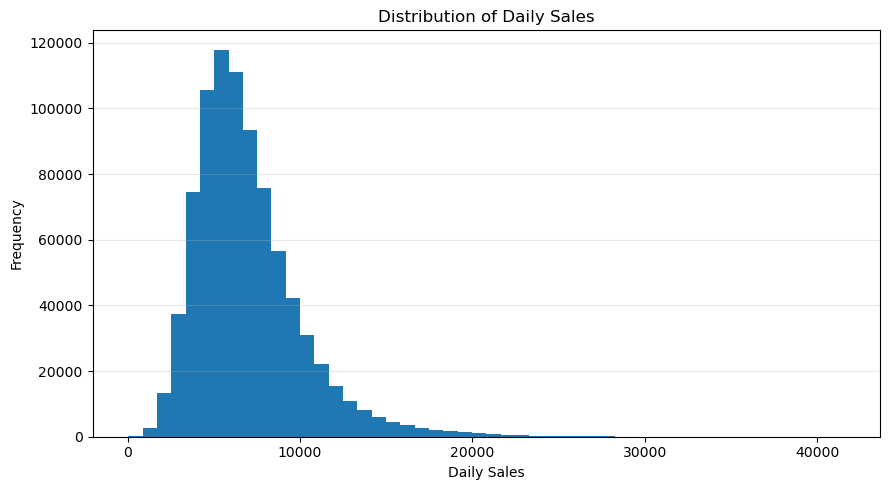

In [63]:
# Sales distribution plot

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(open_df["Sales"], bins=50)

ax.set_title("Distribution of Daily Sales")
ax.set_xlabel("Daily Sales")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "distribution_daily_sales.png", dpi=300, bbox_inches="tight")

plt.show()

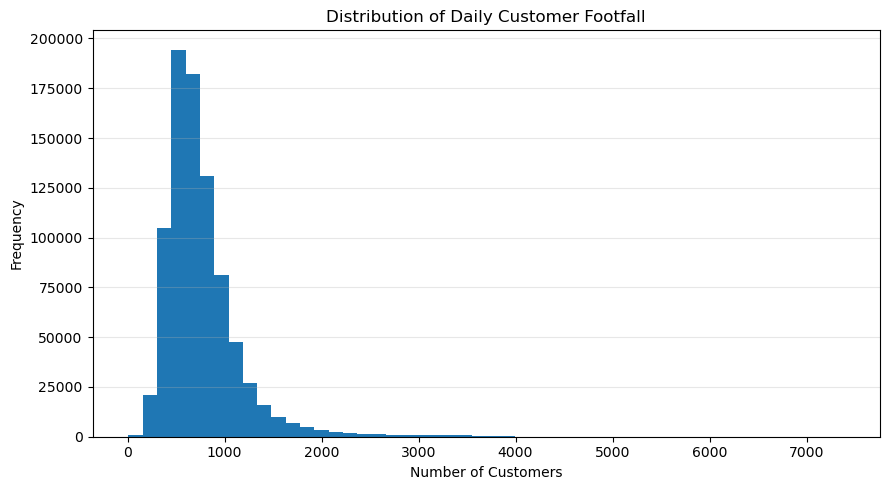

In [64]:
# Customer distribution

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(open_df["Customers"], bins=50)

ax.set_title("Distribution of Daily Customer Footfall")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "distribution_customers.png", dpi=300, bbox_inches="tight")

plt.show()

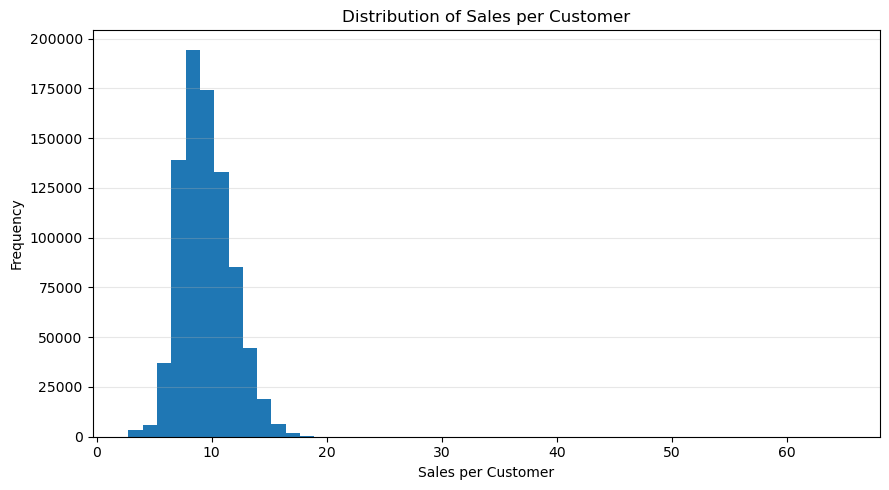

In [65]:
# Sales-per-customer distribution

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(open_df["SalesPerCustomer"], bins=50)

ax.set_title("Distribution of Sales per Customer")
ax.set_xlabel("Sales per Customer")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "distribution_sales_per_customer.png", dpi=300, bbox_inches="tight")

plt.show()

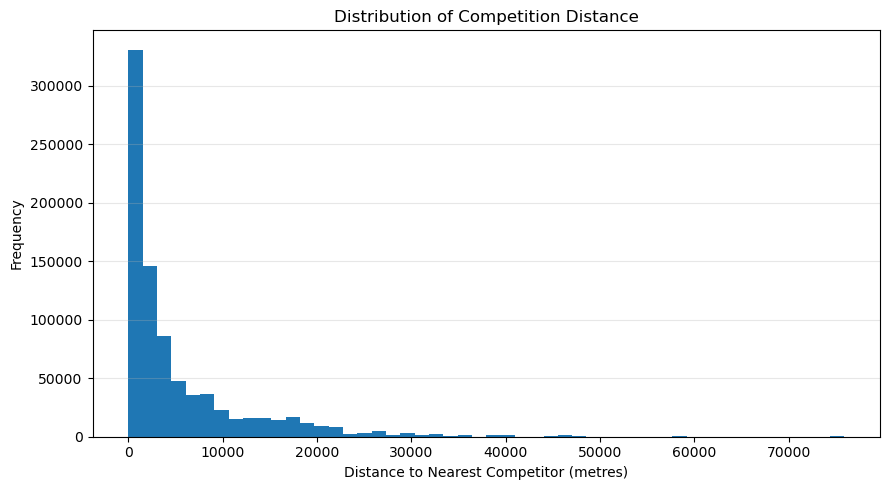

In [66]:
# Competition-distance distribution

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(open_df["CompetitionDistance"].dropna(), bins=50)

ax.set_title("Distribution of Competition Distance")
ax.set_xlabel("Distance to Nearest Competitor (metres)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "distribution_competition_distance.png", dpi=300, bbox_inches="tight")

plt.show()

### Descriptive Statistics Insights

The final analytical dataset contains 844,338 valid operating-day observations across all 1,115 Rossmann stores, covering the period from 1 January 2013 to 31 July 2015.

Total sales over the analysed operating period were approximately 5.87 billion, generated from around 644.04 million customer visits. Average daily sales were approximately 6,955.96, while the median was lower at 6,369. This difference indicates a positively skewed sales distribution, where a smaller number of high-sales days raise the overall mean.

Average daily customer footfall was approximately 762.78 customers, compared with a median of 676. Customer footfall therefore shows more relative variation than sales, reflected by a coefficient of variation of 52.60%, compared with 44.62% for sales.

Average sales per customer were approximately 9.49, with a median of 9.25. The coefficient of variation for this variable was only 23.15%, suggesting that turnover per customer was substantially more stable than either total sales or customer footfall.

Competition distance showed the greatest variability, with a coefficient of variation of 143.08%. The mean distance to the nearest competitor was approximately 5,458 metres, while the median was only 2,320 metres. This confirms that the distribution is strongly right-skewed, with a smaller number of stores located very far from their nearest competitor.

The comparatively low variability in sales per customer suggests that differences in store performance are more strongly associated with customer footfall than with large differences in turnover generated per customer. This makes customer traffic an important factor in explaining store-level sales imbalance.

## Store-Type Performance Analysis

In [67]:
# Store-type summary table

store_type_summary = (open_df.groupby("StoreTypeLabel", observed=True)
    .agg(
        NumberOfStores=("Store", "nunique"),
        OperatingRecords=("Sales", "size"),
        TotalSales=("Sales", "sum"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        SalesStandardDeviation=("Sales", "std"),
        AverageCustomers=("Customers", "mean"),
        MedianCustomers=("Customers", "median"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
)

store_type_summary

,StoreTypeLabel,NumberOfStores,OperatingRecords,TotalSales,AverageDailySales,MedianDailySales,SalesStandardDeviation,AverageCustomers,MedianCustomers,AverageSalesPerCustomer
0,Type A,602,457042,3165334859,6925.697986,6285.0,3277.351589,795.422370,720.0,8.846296
1,Type B,17,15560,159231395,10233.380141,9130.0,5155.729868,2022.211825,1839.5,5.133427
2,Type C,148,112968,783221426,6933.126425,6408.0,2896.958579,815.538073,756.0,8.626227
3,Type D,348,258768,1765392943,6822.300064,6395.0,2556.401455,606.353935,577.0,11.277862


In [68]:
# Sales variability

store_type_summary["SalesCoefficientOfVariationPct"] = (store_type_summary["SalesStandardDeviation"] / store_type_summary["AverageDailySales"]) * 100

In [69]:
store_type_summary = store_type_summary.round({
    "TotalSales": 0,
    "AverageDailySales": 2,
    "MedianDailySales": 2,
    "SalesStandardDeviation": 2,
    "AverageCustomers": 2,
    "MedianCustomers": 2,
    "AverageSalesPerCustomer": 2,
    "SalesCoefficientOfVariationPct": 2
})

store_type_summary

,StoreTypeLabel,NumberOfStores,OperatingRecords,TotalSales,AverageDailySales,MedianDailySales,SalesStandardDeviation,AverageCustomers,MedianCustomers,AverageSalesPerCustomer,SalesCoefficientOfVariationPct
0,Type A,602,457042,3165334859,6925.70,6285.0,3277.35,795.42,720.0,8.85,47.32
1,Type B,17,15560,159231395,10233.38,9130.0,5155.73,2022.21,1839.5,5.13,50.38
2,Type C,148,112968,783221426,6933.13,6408.0,2896.96,815.54,756.0,8.63,41.78
3,Type D,348,258768,1765392943,6822.30,6395.0,2556.40,606.35,577.0,11.28,37.47


In [70]:
# Sales and customer contribution

store_type_summary["SalesContributionPct"] = (store_type_summary["TotalSales"] / store_type_summary["TotalSales"].sum()) * 100

In [71]:
store_type_summary["StoreSharePct"] = (store_type_summary["NumberOfStores"] / store_type_summary["NumberOfStores"].sum()) * 100

In [72]:
store_type_summary[["SalesContributionPct", "StoreSharePct"]] = store_type_summary[["SalesContributionPct", "StoreSharePct"]].round(2)

In [73]:
store_type_summary = store_type_summary[
    [
        "StoreTypeLabel",
        "NumberOfStores",
        "StoreSharePct",
        "OperatingRecords",
        "TotalSales",
        "SalesContributionPct",
        "AverageDailySales",
        "MedianDailySales",
        "AverageCustomers",
        "MedianCustomers",
        "AverageSalesPerCustomer",
        "SalesStandardDeviation",
        "SalesCoefficientOfVariationPct"
    ]
]

store_type_summary

,StoreTypeLabel,NumberOfStores,StoreSharePct,OperatingRecords,TotalSales,SalesContributionPct,AverageDailySales,MedianDailySales,AverageCustomers,MedianCustomers,AverageSalesPerCustomer,SalesStandardDeviation,SalesCoefficientOfVariationPct
0,Type A,602,53.99,457042,3165334859,53.89,6925.70,6285.0,795.42,720.0,8.85,3277.35,47.32
1,Type B,17,1.52,15560,159231395,2.71,10233.38,9130.0,2022.21,1839.5,5.13,5155.73,50.38
2,Type C,148,13.27,112968,783221426,13.34,6933.13,6408.0,815.54,756.0,8.63,2896.96,41.78
3,Type D,348,31.21,258768,1765392943,30.06,6822.30,6395.0,606.35,577.0,11.28,2556.40,37.47


In [74]:
store_type_summary.to_csv(TABLE_DIR / "store_type_performance.csv", index=False)

store_type_summary.to_excel(TABLE_DIR / "store_type_performance.xlsx", index=False)

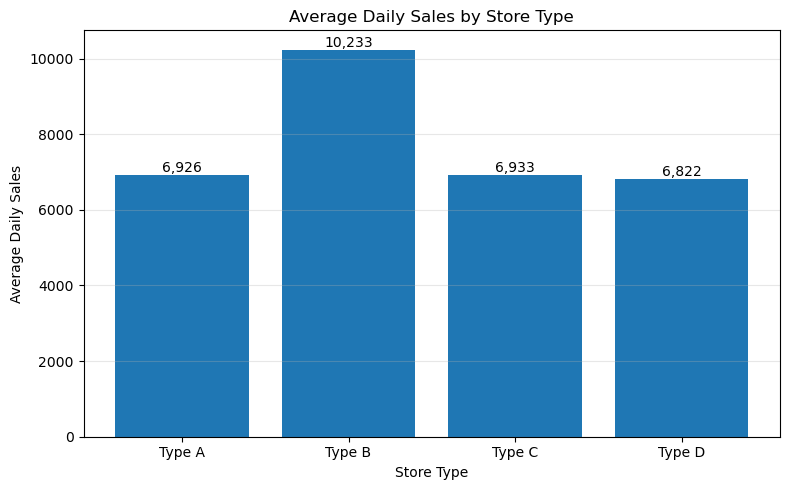

In [75]:
# Average daily sales by store type

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(store_type_summary["StoreTypeLabel"], store_type_summary["AverageDailySales"])

ax.set_title("Average Daily Sales by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(store_type_summary["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_daily_sales_by_store_type.png", dpi=300, bbox_inches="tight")

plt.show()

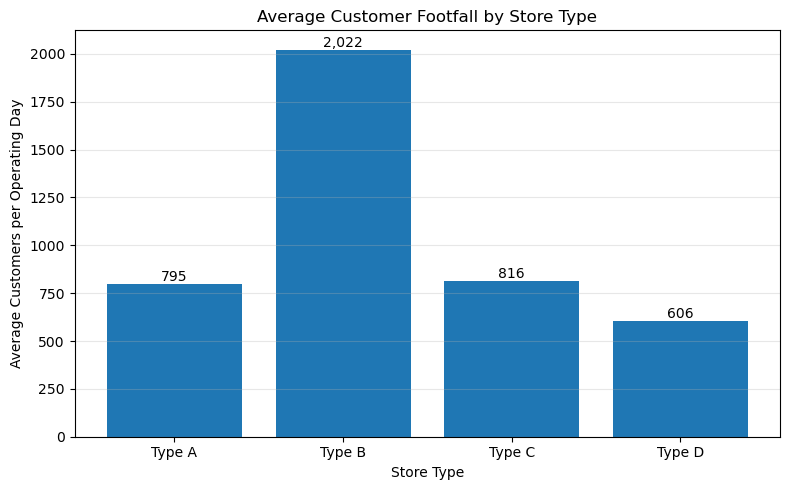

In [76]:
# Average customer footfall

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(store_type_summary["StoreTypeLabel"], store_type_summary["AverageCustomers"])

ax.set_title("Average Customer Footfall by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Customers per Operating Day")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(store_type_summary["AverageCustomers"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_customers_by_store_type.png", dpi=300, bbox_inches="tight")

plt.show()

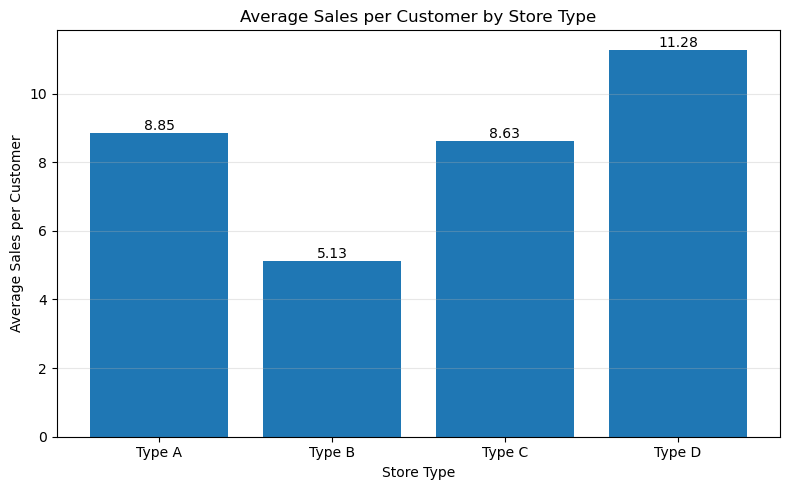

In [77]:
# Sales per customer

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(store_type_summary["StoreTypeLabel"], store_type_summary["AverageSalesPerCustomer"])

ax.set_title("Average Sales per Customer by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Sales per Customer")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(store_type_summary["AverageSalesPerCustomer"]):
    ax.text(i, value, f"{value:.2f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "sales_per_customer_by_store_type.png", dpi=300, bbox_inches="tight")

plt.show()

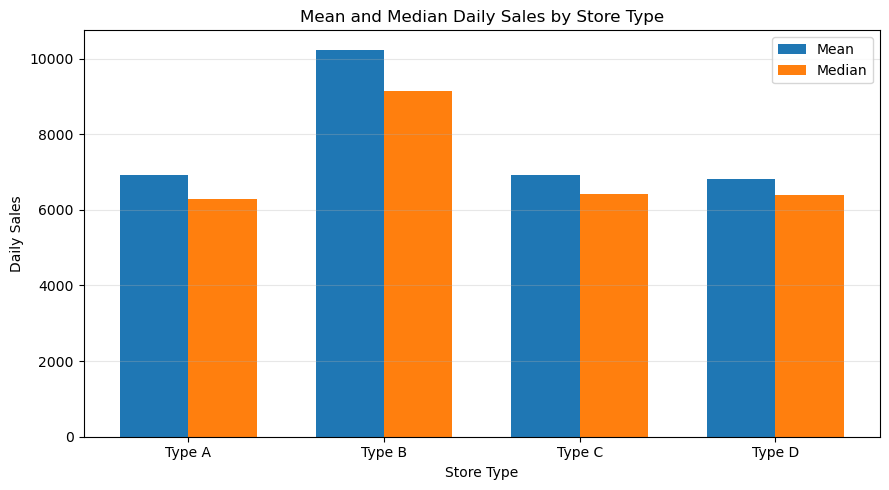

In [78]:
# Comparing average and median sales

x = np.arange(len(store_type_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, store_type_summary["AverageDailySales"], width, label="Mean")

ax.bar(x + width / 2, store_type_summary["MedianDailySales"], width, label="Median")

ax.set_title("Mean and Median Daily Sales by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Daily Sales")
ax.set_xticks(x)
ax.set_xticklabels(store_type_summary["StoreTypeLabel"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "mean_median_sales_by_store_type.png", dpi=300, bbox_inches="tight")

plt.show()

In [79]:
# Store-level summaries within each type

individual_store_summary = (open_df.groupby(["Store", "StoreTypeLabel"], observed=True)
    .agg(
        AverageDailySales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
)

In [80]:
store_type_store_level = (individual_store_summary.groupby("StoreTypeLabel", observed=True)
    .agg(
        NumberOfStores=("Store", "nunique"),
        MeanStoreAverageSales=("AverageDailySales", "mean"),
        MedianStoreAverageSales=("AverageDailySales", "median"),
        MeanStoreAverageCustomers=("AverageCustomers", "mean"),
        MeanStoreSalesPerCustomer=("AverageSalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

store_type_store_level

,StoreTypeLabel,NumberOfStores,MeanStoreAverageSales,MedianStoreAverageSales,MeanStoreAverageCustomers,MeanStoreSalesPerCustomer
0,Type A,602,6913.03,6481.22,792.19,8.87
1,Type B,17,10112.31,9744.60,1999.03,5.13
2,Type C,148,6917.88,6645.84,812.09,8.65
3,Type D,348,6823.89,6695.22,604.22,11.32


In [81]:
store_type_store_level.to_csv(TABLE_DIR / "store_type_store_level_summary.csv", index=False)

### Store-Type Performance Insights

Store performance differed considerably across the four Rossmann store types.

Type B stores recorded the highest average daily sales at approximately 10,233.38 and the highest average customer footfall at around 2,022 customers per operating day. However, Type B also recorded the lowest average sales per customer at only 5.13. This indicates that the strong performance of Type B stores was primarily driven by very high customer volumes rather than high turnover per customer.

Type D stores showed the opposite pattern. They recorded the lowest average customer footfall at approximately 606 customers per operating day, but the highest average sales per customer at 11.28. This suggests that Type D stores serve fewer customers but generate substantially more sales per customer.

Type A and Type C stores showed very similar average daily sales, at approximately 6,926 and 6,933 respectively. Type C recorded slightly higher customer footfall, while Type A recorded slightly higher sales per customer.

Sales consistency also varied across store formats. Type D had the lowest coefficient of variation at 37.47%, indicating the most stable daily sales. Type B had the highest relative variability at 50.38%, suggesting that its performance fluctuated more strongly over time.

These findings demonstrate that strong store performance can arise through different operating patterns. Type B stores depend primarily on high footfall, while Type D stores depend more on higher turnover per customer.

The results for Type B should be interpreted with caution because this category contains only 17 stores, representing 1.52% of the total store network. Although the pattern is strong, the small group size limits direct comparison with the much larger Type A and Type D categories.

Rossmann store types do not follow one uniform performance model. Type B succeeds through high customer volume, while Type D succeeds through higher spending per customer and more stable sales.

## Assortment-Level Performance Analysis

Now we will compare performance across the three assortment levels:

- Basic
- Extra
- Extended

This directly supports Objective 1 because assortment is one of the approved comparison factors.

In [82]:
# Assortment summary

assortment_summary = (open_df.groupby("AssortmentLabel", observed=True)
    .agg(
        NumberOfStores=("Store", "nunique"),
        OperatingRecords=("Sales", "size"),
        TotalSales=("Sales", "sum"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        SalesStandardDeviation=("Sales", "std"),
        AverageCustomers=("Customers", "mean"),
        MedianCustomers=("Customers", "median"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
)

assortment_summary

,AssortmentLabel,NumberOfStores,OperatingRecords,TotalSales,AverageDailySales,MedianDailySales,SalesStandardDeviation,AverageCustomers,MedianCustomers,AverageSalesPerCustomer
0,Basic,593,444875,2945750070,6621.523057,6082.0,2972.050174,748.000978,673.0,9.130807
1,Extended,513,391254,2856484241,7300.843547,6675.0,3183.849717,752.202641,672.0,10.018030
2,Extra,9,8209,70946312,8642.503594,8088.0,3803.116031,2067.550250,1895.0,4.163726


In [83]:
# Variability and contribution measures

assortment_summary["SalesCoefficientOfVariationPct"] = (assortment_summary["SalesStandardDeviation"] / assortment_summary["AverageDailySales"]) * 100

In [84]:
assortment_summary["SalesContributionPct"] = (assortment_summary["TotalSales"] / assortment_summary["TotalSales"].sum()) * 100

In [85]:
assortment_summary["StoreSharePct"] = (assortment_summary["NumberOfStores"] / assortment_summary["NumberOfStores"].sum()) * 100

In [86]:
assortment_summary = assortment_summary.round({
    "TotalSales": 0,
    "AverageDailySales": 2,
    "MedianDailySales": 2,
    "SalesStandardDeviation": 2,
    "AverageCustomers": 2,
    "MedianCustomers": 2,
    "AverageSalesPerCustomer": 2,
    "SalesCoefficientOfVariationPct": 2,
    "SalesContributionPct": 2,
    "StoreSharePct": 2
})

In [87]:
assortment_summary = assortment_summary[
    [
        "AssortmentLabel",
        "NumberOfStores",
        "StoreSharePct",
        "OperatingRecords",
        "TotalSales",
        "SalesContributionPct",
        "AverageDailySales",
        "MedianDailySales",
        "AverageCustomers",
        "MedianCustomers",
        "AverageSalesPerCustomer",
        "SalesStandardDeviation",
        "SalesCoefficientOfVariationPct"
    ]
]

assortment_summary

,AssortmentLabel,NumberOfStores,StoreSharePct,OperatingRecords,TotalSales,SalesContributionPct,AverageDailySales,MedianDailySales,AverageCustomers,MedianCustomers,AverageSalesPerCustomer,SalesStandardDeviation,SalesCoefficientOfVariationPct
0,Basic,593,53.18,444875,2945750070,50.16,6621.52,6082.0,748.00,673.0,9.13,2972.05,44.88
1,Extended,513,46.01,391254,2856484241,48.64,7300.84,6675.0,752.20,672.0,10.02,3183.85,43.61
2,Extra,9,0.81,8209,70946312,1.21,8642.50,8088.0,2067.55,1895.0,4.16,3803.12,44.00


In [88]:
assortment_summary.to_csv(TABLE_DIR / "assortment_performance.csv", index=False)

assortment_summary.to_excel(TABLE_DIR / "assortment_performance.xlsx", index=False)

In [89]:
 # Store-level assortment summary

individual_store_assortment = (open_df
    .groupby(
        ["Store", "AssortmentLabel"],
        observed=True
    )
    .agg(
        AverageDailySales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
)

In [90]:
assortment_store_level = (individual_store_assortment
    .groupby("AssortmentLabel", observed=True)
    .agg(
        NumberOfStores=("Store", "nunique"),
        MeanStoreAverageSales=("AverageDailySales", "mean"),
        MedianStoreAverageSales=("AverageDailySales", "median"),
        MeanStoreAverageCustomers=("AverageCustomers", "mean"),
        MeanStoreSalesPerCustomer=("AverageSalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

assortment_store_level

,AssortmentLabel,NumberOfStores,MeanStoreAverageSales,MedianStoreAverageSales,MeanStoreAverageCustomers,MeanStoreSalesPerCustomer
0,Basic,593,6597.36,6250.41,740.87,9.18
1,Extended,513,7296.01,6906.44,747.74,10.07
2,Extra,9,8558.31,7687.46,2045.99,4.17


In [91]:
assortment_store_level.to_csv(TABLE_DIR / "assortment_store_level_summary.csv", index=False)

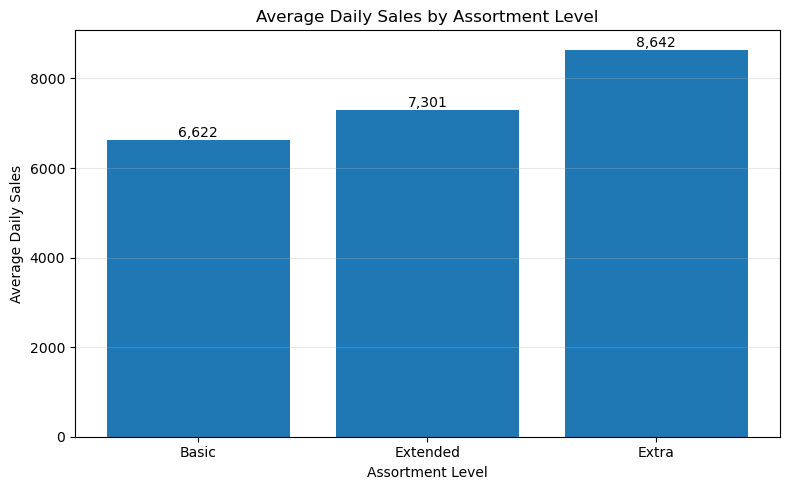

In [92]:
# Average daily sales by assortment

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(assortment_summary["AssortmentLabel"], assortment_summary["AverageDailySales"])

ax.set_title("Average Daily Sales by Assortment Level")
ax.set_xlabel("Assortment Level")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(assortment_summary["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_daily_sales_by_assortment.png", dpi=300, bbox_inches="tight")

plt.show()

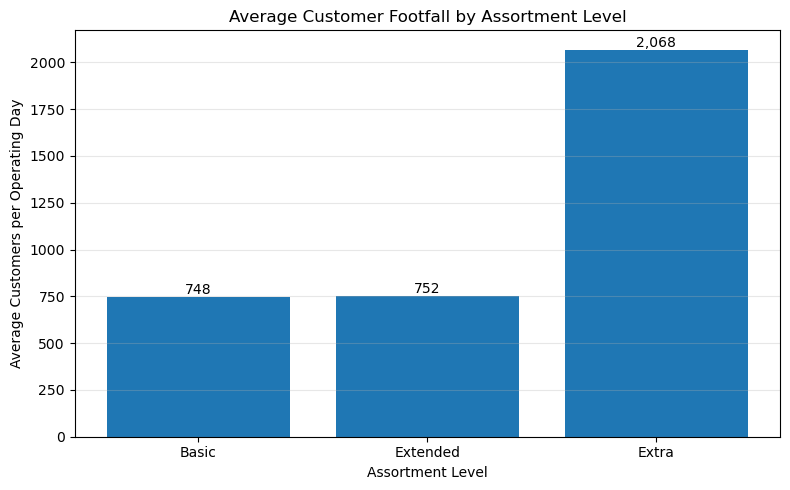

In [93]:
# Average customer footfall

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(assortment_summary["AssortmentLabel"], assortment_summary["AverageCustomers"])

ax.set_title("Average Customer Footfall by Assortment Level")
ax.set_xlabel("Assortment Level")
ax.set_ylabel("Average Customers per Operating Day")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(assortment_summary["AverageCustomers"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_customers_by_assortment.png", dpi=300, bbox_inches="tight")

plt.show()

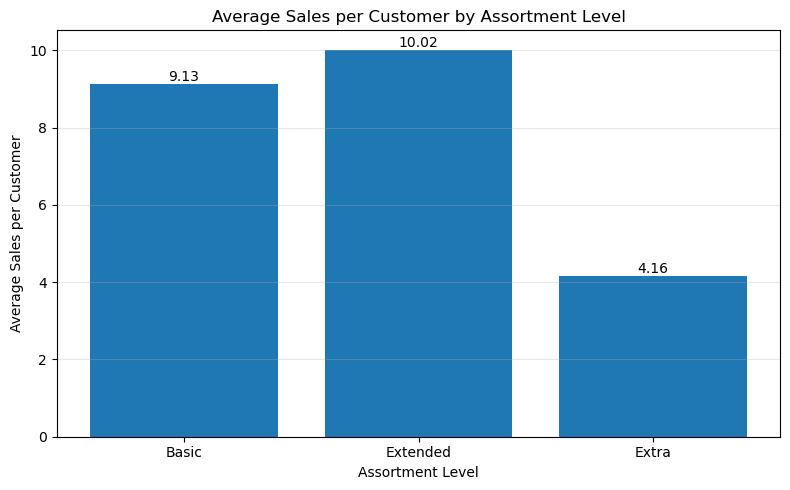

In [94]:
# Sales per customer

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(assortment_summary["AssortmentLabel"], assortment_summary["AverageSalesPerCustomer"])

ax.set_title("Average Sales per Customer by Assortment Level")
ax.set_xlabel("Assortment Level")
ax.set_ylabel("Average Sales per Customer")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(assortment_summary["AverageSalesPerCustomer"]):
    ax.text(i, value, f"{value:.2f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "sales_per_customer_by_assortment.png", dpi=300, bbox_inches="tight")

plt.show()

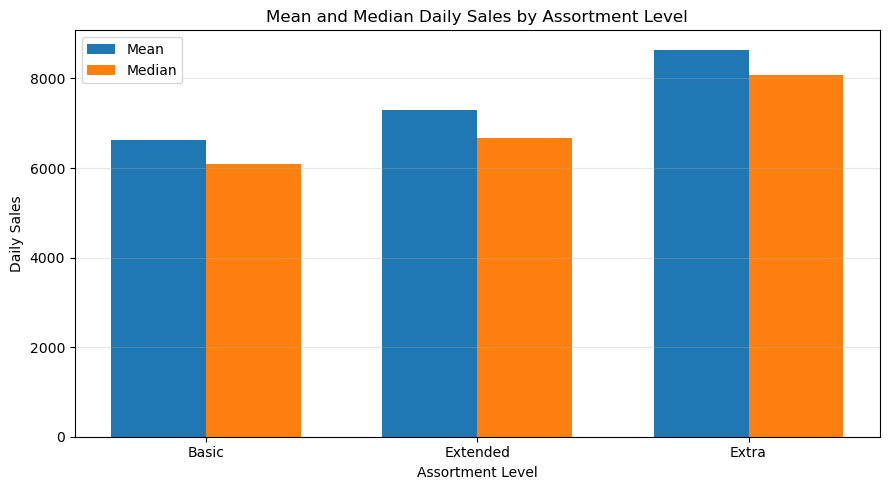

In [95]:
# Mean and median sales

x = np.arange(len(assortment_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, assortment_summary["AverageDailySales"], width, label="Mean")

ax.bar(x + width / 2, assortment_summary["MedianDailySales"], width, label="Median")

ax.set_title("Mean and Median Daily Sales by Assortment Level")
ax.set_xlabel("Assortment Level")
ax.set_ylabel("Daily Sales")
ax.set_xticks(x)
ax.set_xticklabels(assortment_summary["AssortmentLabel"])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "mean_median_sales_by_assortment.png", dpi=300, bbox_inches="tight")

plt.show()

### Assortment-Level Performance Insights

Performance differed across the three assortment levels.

Stores with an Extra assortment recorded the highest average daily sales at approximately 8,642.50. However, this group contained only 9 stores, representing just 0.81% of the total store network. Its results should therefore be interpreted cautiously because the category is much smaller than the Basic and Extended groups.

Extended-assortment stores generated average daily sales of approximately 7,300.84, compared with 6,621.52 for Basic-assortment stores. Extended stores also recorded the highest average sales per customer at 10.02, while Basic stores recorded 9.13.

Average customer footfall was very similar for Basic and Extended stores, at approximately 748 and 752 customers respectively. This suggests that the stronger sales performance of Extended stores was not mainly driven by attracting substantially more customers. Instead, it was associated with higher sales generated per customer.

Extra-assortment stores followed a different pattern. They served an average of approximately 2,068 customers per operating day, far above the other assortment groups, but recorded the lowest average sales per customer at only 4.16. Their high total performance was therefore driven primarily by exceptionally high customer volume.

Sales variability was relatively similar across all assortment levels. The coefficient of variation ranged from 43.61% for Extended assortment to 44.88% for Basic assortment, indicating no major difference in relative sales stability across the three groups.

The comparison between Basic and Extended assortment stores suggests that a broader product range may support higher customer spending without requiring substantially greater customer traffic. This indicates that assortment depth may be associated with stronger customer value rather than simply higher footfall.

The Extra category behaves similarly to Type B stores:

- very high footfall
- high average sales
- very low sales per customer
- very small number of stores

This may not be a coincidence. It is likely that many or all Extra-assortment stores belong to Type B.

In [96]:
pd.crosstab(open_df["StoreTypeLabel"], open_df["AssortmentLabel"])

AssortmentLabel,Basic,Extended,Extra
StoreTypeLabel,,,
Type A,286028,171014,0
Type B,6409,942,8209
Type C,58554,54414,0
Type D,93884,164884,0


In [97]:
store_type_assortment_cross = (open_df[["Store", "StoreTypeLabel", "AssortmentLabel"]].drop_duplicates(subset="Store"))

pd.crosstab(store_type_assortment_cross["StoreTypeLabel"], store_type_assortment_cross["AssortmentLabel"])

AssortmentLabel,Basic,Extended,Extra
StoreTypeLabel,,,
Type A,381,221,0
Type B,7,1,9
Type C,77,71,0
Type D,128,220,0


### Relationship Between Store Type and Assortment

A cross-tabulation of unique stores showed that assortment level is not distributed independently across store types.

All 9 stores with an Extra assortment belonged to Store Type B. No Type A, Type C, or Type D stores offered the Extra assortment. Type B also included 7 Basic-assortment stores and 1 Extended-assortment store.

This overlap is important because both Type B stores and Extra-assortment stores recorded high average daily sales, very high customer footfall, and low sales per customer. Therefore, the performance observed for the Extra assortment category cannot be attributed to assortment level alone.

The result may instead reflect the operating characteristics of Type B stores. Consequently, the Extra-assortment findings are interpreted as a combined store-type and assortment pattern rather than as an independent assortment effect.

In [99]:
store_type_assortment_summary = (open_df
    .groupby(
        ["StoreTypeLabel", "AssortmentLabel"],
        observed=True
    )
    .agg(
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

store_type_assortment_summary

,StoreTypeLabel,AssortmentLabel,NumberOfStores,AverageDailySales,AverageCustomers,AverageSalesPerCustomer
0,Type A,Basic,381,6538.19,759.31,8.74
1,Type A,Extended,221,7573.82,855.82,9.02
2,Type B,Basic,7,11133.99,1804.98,6.28
3,Type B,Extended,1,17969.56,3105.05,5.76
4,Type B,Extra,9,8642.50,2067.55,4.16
5,Type C,Basic,77,6835.75,839.96,8.26
6,Type C,Extended,71,7037.91,789.25,9.02
7,Type D,Basic,128,6433.76,584.03,11.05
8,Type D,Extended,220,7043.53,619.06,11.41


### Store Type and Assortment Interaction

The relationship between assortment level and store performance was examined within each store type to reduce the influence of overlap between store format and assortment.

Among Type A stores, Extended assortment was associated with higher average daily sales, customer footfall, and sales per customer than Basic assortment. This suggests that the stronger performance of Extended Type A stores was supported by both greater customer traffic and slightly higher customer spending.

Among Type C stores, Extended assortment also recorded higher average daily sales. However, these stores served fewer customers than Basic Type C stores. Their advantage therefore appears to come mainly from higher sales per customer rather than higher footfall.

Among Type D stores, Extended assortment again outperformed Basic assortment in average daily sales, customer footfall, and sales per customer.

Overall, Extended assortment was associated with higher average sales across Types A, C, and D. However, the source of this advantage differed by store type. In some formats it was linked to higher customer traffic, while in others it was linked more strongly to higher turnover per customer.

Type B results were interpreted cautiously because the subgroup sizes were very small. In particular, the Extended Type B category contained only one store, so its unusually high performance cannot be generalised to the wider network.

## Individual Store Performance Analysis

In [102]:
# Store level summary

store_performance = (open_df.groupby("Store")
    .agg(
        OperatingDays=("Date", "count"),
        TotalSales=("Sales", "sum"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        SalesStandardDeviation=("Sales", "std"),
        AverageCustomers=("Customers", "mean"),
        MedianCustomers=("Customers", "median"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean"),
        PromoDays=("Promo", "sum")
    )
    .reset_index()
)

In [103]:
# Sales variability 

store_performance["SalesCoefficientOfVariationPct"] = (store_performance["SalesStandardDeviation"] / store_performance["AverageDailySales"]) * 100

In [104]:
store_characteristics = store[
    [
        "Store",
        "StoreType",
        "Assortment",
        "CompetitionDistance",
        "Promo2"
    ]
].copy()

store_characteristics["StoreTypeLabel"] = (store_characteristics["StoreType"].map(store_type_mapping))

store_characteristics["AssortmentLabel"] = (store_characteristics["Assortment"].map(assortment_mapping))

In [105]:
store_performance = store_performance.merge(store_characteristics, on="Store", how="left")

In [106]:
# Store rankings

store_performance["AverageSalesRank"] = (
    store_performance["AverageDailySales"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

store_performance["CustomerRank"] = (
    store_performance["AverageCustomers"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

store_performance["SalesPerCustomerRank"] = (
    store_performance["AverageSalesPerCustomer"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

In [107]:
store_performance = store_performance.round({
    "TotalSales": 0,
    "AverageDailySales": 2,
    "MedianDailySales": 2,
    "SalesStandardDeviation": 2,
    "AverageCustomers": 2,
    "MedianCustomers": 2,
    "AverageSalesPerCustomer": 2,
    "SalesCoefficientOfVariationPct": 2
})

In [108]:
# Top 10 by average daily sales

top_10_stores = (
    store_performance
    .sort_values("AverageDailySales", ascending=False)
    .head(10)
)

top_10_stores[
    [
        "Store",
        "StoreTypeLabel",
        "AssortmentLabel",
        "AverageDailySales",
        "AverageCustomers",
        "AverageSalesPerCustomer",
        "SalesCoefficientOfVariationPct"
    ]
]

,Store,StoreTypeLabel,AssortmentLabel,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,SalesCoefficientOfVariationPct
816,817,Type A,Basic,21757.48,3130.57,6.94,21.49
261,262,Type B,Basic,20718.52,3402.01,6.06,22.53
1113,1114,Type A,Extended,20666.56,3200.95,6.45,16.71
250,251,Type A,Extended,19123.07,2450.49,7.77,18.55
841,842,Type D,Extended,18574.80,1149.24,16.06,20.40
512,513,Type A,Basic,18179.09,2096.34,8.63,18.07
561,562,Type B,Extended,17969.56,3105.05,5.76,16.32
787,788,Type A,Extended,17961.91,1717.90,10.44,17.54
382,383,Type A,Extended,17294.72,2205.45,7.81,16.11
755,756,Type A,Extended,16574.82,2346.57,7.04,23.61


In [109]:
# Bottom 10 by average daily sales

bottom_10_stores = (
    store_performance
    .sort_values("AverageDailySales")
    .head(10)
)

bottom_10_stores[
    [
        "Store",
        "StoreTypeLabel",
        "AssortmentLabel",
        "AverageDailySales",
        "AverageCustomers",
        "AverageSalesPerCustomer",
        "SalesCoefficientOfVariationPct"
    ]
]

,Store,StoreTypeLabel,AssortmentLabel,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,SalesCoefficientOfVariationPct
306,307,Type A,Basic,2703.74,307.81,8.64,38.20
542,543,Type C,Basic,2790.38,240.18,11.23,44.36
197,198,Type A,Basic,2900.60,338.48,8.23,55.08
207,208,Type C,Basic,2936.29,413.47,7.05,24.40
840,841,Type A,Basic,2972.61,412.17,7.13,36.88
253,254,Type D,Basic,3005.98,258.67,11.49,27.68
793,794,Type C,Extended,3083.81,521.83,5.89,18.68
218,219,Type A,Basic,3133.71,406.44,7.67,26.24
209,210,Type D,Basic,3193.98,326.26,9.68,26.59
424,425,Type D,Extended,3237.66,434.38,7.39,27.71


In [110]:
# Most stable stores

most_stable_stores = (store_performance.sort_values("SalesCoefficientOfVariationPct").head(10))

In [111]:
# Least stable stores

most_volatile_stores = (store_performance.sort_values("SalesCoefficientOfVariationPct",ascending=False).head(10))

In [112]:
# Store-performance matrix

median_store_sales = store_performance["AverageDailySales"].median()
median_store_customers = store_performance["AverageCustomers"].median()

conditions = [
    (
        store_performance["AverageDailySales"] >= median_store_sales
    ) &
    (
        store_performance["AverageCustomers"] >= median_store_customers
    ),
    (
        store_performance["AverageDailySales"] >= median_store_sales
    ) &
    (
        store_performance["AverageCustomers"] < median_store_customers
    ),
    (
        store_performance["AverageDailySales"] < median_store_sales
    ) &
    (
        store_performance["AverageCustomers"] >= median_store_customers
    )
]

labels = ["High Sales / High Footfall", "High Sales / Low Footfall", "Low Sales / High Footfall"]

store_performance["PerformanceSegment"] = np.select(conditions, labels, default="Low Sales / Low Footfall")

In [113]:
performance_segment_summary = (store_performance
    .groupby("PerformanceSegment")
    .agg(
        NumberOfStores=("Store", "count"),
        AverageDailySales=("AverageDailySales", "mean"),
        AverageCustomers=("AverageCustomers", "mean"),
        AverageSalesPerCustomer=("AverageSalesPerCustomer", "mean"),
        AverageSalesVariability=(
            "SalesCoefficientOfVariationPct",
            "mean"
        )
    )
    .reset_index()
    .round(2)
)

performance_segment_summary

,PerformanceSegment,NumberOfStores,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,AverageSalesVariability
0,High Sales / High Footfall,451,8935.46,1020.44,9.09,25.84
1,High Sales / Low Footfall,107,7354.76,595.40,12.31,26.71
2,Low Sales / High Footfall,107,5896.34,784.57,7.55,27.96
3,Low Sales / Low Footfall,450,5076.34,518.82,9.83,28.39


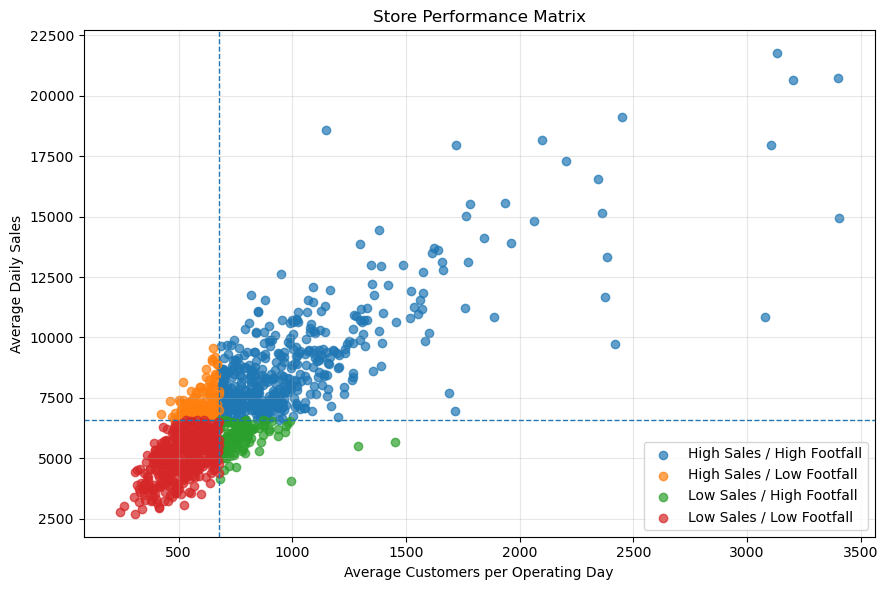

In [114]:
# Plotting the performance matrix

fig, ax = plt.subplots(figsize=(9, 6))

for segment, group in store_performance.groupby("PerformanceSegment"):
    ax.scatter(group["AverageCustomers"], group["AverageDailySales"], label=segment, alpha=0.7)

ax.axvline(median_store_customers, linestyle="--", linewidth=1)

ax.axhline(median_store_sales, linestyle="--", linewidth=1)

ax.set_title("Store Performance Matrix")
ax.set_xlabel("Average Customers per Operating Day")
ax.set_ylabel("Average Daily Sales")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(PLOT_DIR / "store_performance_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [115]:
store_performance.to_csv(TABLE_DIR / "individual_store_performance.csv", index=False)

top_10_stores.to_csv(TABLE_DIR / "top_10_stores_by_average_sales.csv", index=False)

bottom_10_stores.to_csv(TABLE_DIR / "bottom_10_stores_by_average_sales.csv", index=False)

performance_segment_summary.to_csv(TABLE_DIR / "store_performance_segments.csv", index=False)

### Individual Store Performance Insights

Store-level performance varied substantially across the Rossmann network.

Store 817 recorded the highest average daily sales at approximately 21,757.48, followed by Store 262 at 20,718.52 and Store 1114 at 20,666.56. The highest-performing stores were not concentrated in one single format: the top ten included Type A, Type B and Type D stores, with both Basic and Extended assortments represented.

Most of the top-performing stores combined high sales with high customer footfall. For example, Store 817 served an average of approximately 3,131 customers per operating day, while Store 262 served around 3,402. This indicates that high sales among the leading stores were generally supported by strong customer volume.

However, not all top-performing stores relied on the same model. Store 842 recorded average daily sales of approximately 18,574.80 with only 1,149 customers, but generated the highest sales per customer among the top ten at 16.06. This suggests that some stores achieve strong sales through higher customer value rather than exceptionally high footfall.

The top-performing stores also showed relatively low sales variability, with coefficients of variation mostly between approximately 16% and 24%. This suggests that their strong performance was generally consistent rather than being driven only by occasional peak days.

### Low-Performing Stores

The lowest-performing stores recorded average daily sales between approximately 2,704 and 3,238.

Store 307 had the lowest average daily sales at 2,703.74 and served around 308 customers per operating day. Several of the lowest-performing stores were Type A or Type D stores with Basic assortments, although the bottom group also included Type C and Extended-assortment stores.

Low sales were not always associated with low sales per customer. For example, Store 254 recorded average daily sales of only 3,005.98 but generated 11.49 in sales per customer. Its weaker overall performance was therefore more closely related to low customer footfall than weak customer value.

This indicates that low-performing stores should not be treated as a single group. Some appear to face a customer-traffic problem, while others may have lower sales per customer or a combination of both.

### Store Performance Segmentation

The store network was divided into four performance groups using the median values of average daily sales and customer footfall.

A total of 451 stores were classified as High Sales / High Footfall. These stores achieved average daily sales of approximately 8,935.46 and served around 1,020 customers per operating day.

A further 107 stores were classified as High Sales / Low Footfall. These stores achieved average daily sales of approximately 7,354.76 despite serving only around 595 customers per day. Their average sales per customer were the highest among all segments at 12.31, indicating that their performance was driven by higher customer value rather than volume.

Another 107 stores were classified as Low Sales / High Footfall. Although these stores served an average of approximately 785 customers per day, their average sales per customer were the lowest at 7.55. This suggests that their main challenge is not attracting customers, but generating sufficient turnover from each visit.

The remaining 450 stores were classified as Low Sales / Low Footfall. These stores recorded average daily sales of approximately 5,076.34 and average customer footfall of around 519. This group represents the clearest performance concern because both traffic and sales are relatively weak.

The segmentation shows that store underperformance arises through different mechanisms.

High Sales / Low Footfall stores may benefit from protecting customer value and maintaining the product or assortment conditions that support higher spending per visit.

Low Sales / High Footfall stores may require stronger cross-selling, assortment review, or more effective promotional design because they attract customers but generate relatively low sales per customer.

Low Sales / Low Footfall stores require the greatest attention, as both demand and turnover are weak. These stores may need store-specific investigation covering local competition, assortment, promotion response, and holiday patterns.

###

## Promotion Effectiveness Analysis

We will first compare promotional and non-promotional days overall, then break the results down by store type, assortment, and store.

In [119]:
# Overall promotion comparison

promo_summary = (open_df
    .groupby("PromoLabel")
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageSales=("Sales", "mean"),
        MedianSales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        MedianCustomers=("Customers", "median"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean"),
        SalesStandardDeviation=("Sales", "std")
    )
    .reset_index()
)

promo_summary["SalesCoefficientOfVariationPct"] = (
    promo_summary["SalesStandardDeviation"] /
    promo_summary["AverageSales"]
) * 100

promo_summary = promo_summary.round(2)

promo_summary

,PromoLabel,OperatingRecords,NumberOfStores,AverageSales,MedianSales,AverageCustomers,MedianCustomers,AverageSalesPerCustomer,SalesStandardDeviation,SalesCoefficientOfVariationPct
0,No Promotion,467463,1115,5929.83,5459.0,696.91,610.0,8.94,2629.27,44.34
1,Promotion,376875,1115,8228.74,7650.0,844.48,757.0,10.18,3175.25,38.59


In [120]:
# Overall promotional uplift

promo_lookup = promo_summary.set_index("PromoLabel")

promo_sales = promo_lookup.loc["Promotion", "AverageSales"]
nonpromo_sales = promo_lookup.loc["No Promotion", "AverageSales"]

promo_customers = promo_lookup.loc["Promotion", "AverageCustomers"]
nonpromo_customers = promo_lookup.loc["No Promotion", "AverageCustomers"]

promo_sales_per_customer = promo_lookup.loc["Promotion", "AverageSalesPerCustomer"]

nonpromo_sales_per_customer = promo_lookup.loc["No Promotion", "AverageSalesPerCustomer"]

sales_uplift_pct = ((promo_sales - nonpromo_sales) / nonpromo_sales) * 100

customer_uplift_pct = ((promo_customers - nonpromo_customers) / nonpromo_customers) * 100

sales_per_customer_uplift_pct = ((promo_sales_per_customer - nonpromo_sales_per_customer) / nonpromo_sales_per_customer) * 100

overall_promo_uplift = pd.DataFrame({
    "Measure": [
        "Average Sales",
        "Average Customers",
        "Average Sales per Customer"
    ],
    "NonPromotionValue": [
        nonpromo_sales,
        nonpromo_customers,
        nonpromo_sales_per_customer
    ],
    "PromotionValue": [
        promo_sales,
        promo_customers,
        promo_sales_per_customer
    ],
    "UpliftPct": [
        sales_uplift_pct,
        customer_uplift_pct,
        sales_per_customer_uplift_pct
    ]
}).round(2)

overall_promo_uplift

,Measure,NonPromotionValue,PromotionValue,UpliftPct
0,Average Sales,5929.83,8228.74,38.77
1,Average Customers,696.91,844.48,21.17
2,Average Sales per Customer,8.94,10.18,13.87


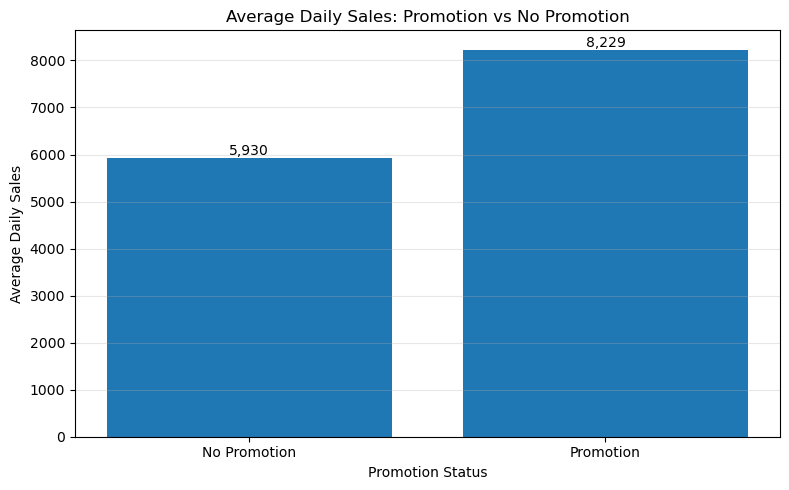

In [121]:
# Promo vs non-promo average sales

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(promo_summary["PromoLabel"], promo_summary["AverageSales"])

ax.set_title("Average Daily Sales: Promotion vs No Promotion")
ax.set_xlabel("Promotion Status")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(promo_summary["AverageSales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "promo_vs_nonpromo_average_sales.png", dpi=300, bbox_inches="tight")

plt.show()

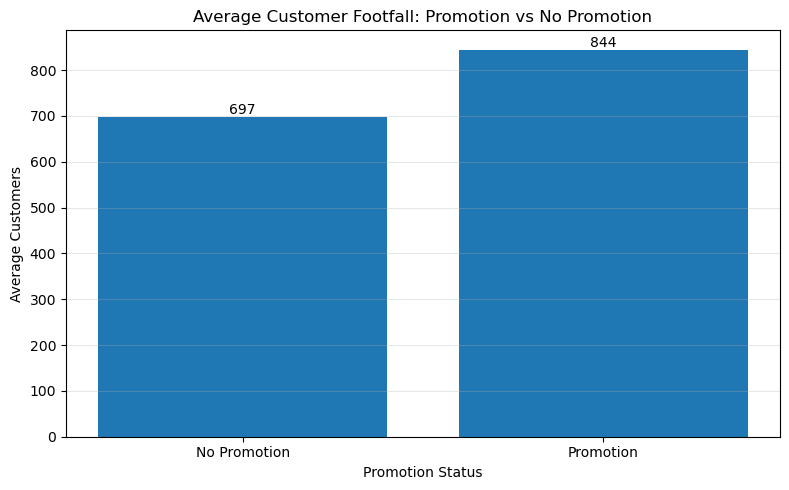

In [122]:
# Promo vs non-promo customers

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(promo_summary["PromoLabel"], promo_summary["AverageCustomers"])

ax.set_title("Average Customer Footfall: Promotion vs No Promotion")
ax.set_xlabel("Promotion Status")
ax.set_ylabel("Average Customers")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(promo_summary["AverageCustomers"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "promo_vs_nonpromo_customers.png", dpi=300, bbox_inches="tight")

plt.show()

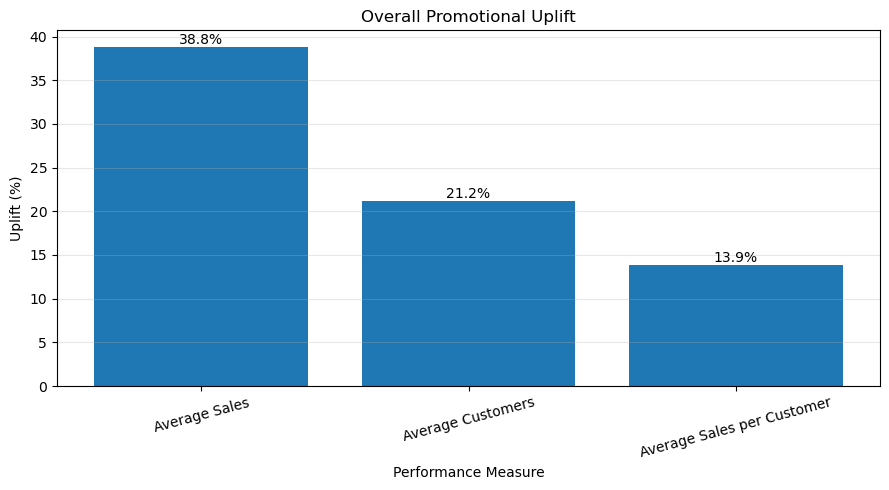

In [123]:
# Promotion uplift measures

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(overall_promo_uplift["Measure"], overall_promo_uplift["UpliftPct"])

ax.set_title("Overall Promotional Uplift")
ax.set_xlabel("Performance Measure")
ax.set_ylabel("Uplift (%)")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(overall_promo_uplift["UpliftPct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(PLOT_DIR / "overall_promotional_uplift.png", dpi=300, bbox_inches="tight")

plt.show()

In [124]:
# Promotion analysis by store type

promo_store_type = (open_df
    .groupby(
        ["StoreTypeLabel", "PromoLabel"],
        observed=True
    )
    .agg(
        OperatingRecords=("Sales", "size"),
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

promo_store_type

,StoreTypeLabel,PromoLabel,OperatingRecords,AverageSales,AverageCustomers,AverageSalesPerCustomer
0,Type A,No Promotion,252532,5809.05,713.88,8.36
1,Type A,Promotion,204510,8304.55,896.12,9.45
2,Type B,No Promotion,9622,9567.86,1942.01,5.01
3,Type B,Promotion,5938,11311.80,2152.18,5.33
4,Type C,No Promotion,62235,6028.55,758.77,8.10
5,Type C,Promotion,50733,8042.79,885.17,9.27
6,Type D,No Promotion,143074,5855.39,556.31,10.60
7,Type D,Promotion,115694,8018.04,668.25,12.12


In [125]:
# Sales

promo_store_type_sales = (promo_store_type
    .pivot(
        index="StoreTypeLabel",
        columns="PromoLabel",
        values="AverageSales"
    )
    .reset_index()
)

promo_store_type_sales["SalesUpliftPct"] = ((promo_store_type_sales["Promotion"] - promo_store_type_sales["No Promotion"]) / promo_store_type_sales["No Promotion"]) * 100

promo_store_type_sales = promo_store_type_sales.round(2)

promo_store_type_sales

PromoLabel,StoreTypeLabel,No Promotion,Promotion,SalesUpliftPct
0,Type A,5809.05,8304.55,42.96
1,Type B,9567.86,11311.80,18.23
2,Type C,6028.55,8042.79,33.41
3,Type D,5855.39,8018.04,36.93


In [126]:
# Csutomers

promo_store_type_customers = (
    promo_store_type
    .pivot(
        index="StoreTypeLabel",
        columns="PromoLabel",
        values="AverageCustomers"
    )
    .reset_index()
)

promo_store_type_customers["CustomerUpliftPct"] = ((promo_store_type_customers["Promotion"] - promo_store_type_customers["No Promotion"]) / promo_store_type_customers["No Promotion"]) * 100

promo_store_type_customers = (promo_store_type_customers.round(2))

promo_store_type_customers

PromoLabel,StoreTypeLabel,No Promotion,Promotion,CustomerUpliftPct
0,Type A,713.88,896.12,25.53
1,Type B,1942.01,2152.18,10.82
2,Type C,758.77,885.17,16.66
3,Type D,556.31,668.25,20.12


In [127]:
# Sales per store

promo_store_type_spc = (
    promo_store_type
    .pivot(
        index="StoreTypeLabel",
        columns="PromoLabel",
        values="AverageSalesPerCustomer"
    )
    .reset_index()
)

promo_store_type_spc["SalesPerCustomerUpliftPct"] = ((promo_store_type_spc["Promotion"] - promo_store_type_spc["No Promotion"]) / promo_store_type_spc["No Promotion"]) * 100

promo_store_type_spc = promo_store_type_spc.round(2)

promo_store_type_spc

PromoLabel,StoreTypeLabel,No Promotion,Promotion,SalesPerCustomerUpliftPct
0,Type A,8.36,9.45,13.04
1,Type B,5.01,5.33,6.39
2,Type C,8.10,9.27,14.44
3,Type D,10.60,12.12,14.34


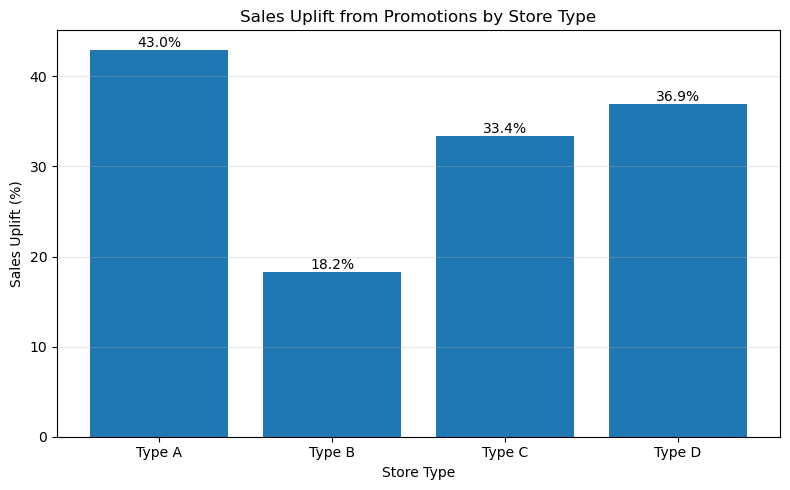

In [128]:
# Sales uplift by store type

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(promo_store_type_sales["StoreTypeLabel"], promo_store_type_sales["SalesUpliftPct"])

ax.set_title("Sales Uplift from Promotions by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Sales Uplift (%)")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(promo_store_type_sales["SalesUpliftPct"]):
    ax.text(i, value, f"{value:.1f}%", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "promotion_sales_uplift_by_store_type.png", dpi=300, bbox_inches="tight")

plt.show()

In [129]:
# Promotion analysis by assortment

promo_assortment = (open_df
    .groupby(
        ["AssortmentLabel", "PromoLabel"],
        observed=True
    )
    .agg(
        OperatingRecords=("Sales", "size"),
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

promo_assortment

,AssortmentLabel,PromoLabel,OperatingRecords,AverageSales,AverageCustomers,AverageSalesPerCustomer
0,Basic,No Promotion,245967,5560.21,674.68,8.58
1,Basic,Promotion,198908,7933.93,838.67,9.81
2,Extended,No Promotion,216419,6291.96,691.33,9.46
3,Extended,Promotion,174835,8549.69,827.55,10.71
4,Extra,No Promotion,5077,8399.85,2011.50,4.17
5,Extra,Promotion,3132,9035.84,2158.41,4.16


In [132]:
# Sales uplift

promo_assortment_sales = (promo_assortment
    .pivot(
        index="AssortmentLabel",
        columns="PromoLabel",
        values="AverageSales"
    )
    .reset_index()
)

promo_assortment_sales["SalesUpliftPct"] = ((promo_assortment_sales["Promotion"] - promo_assortment_sales["No Promotion"]) / promo_assortment_sales["No Promotion"]) * 100

promo_assortment_sales = promo_assortment_sales.round(2)

promo_assortment_sales

PromoLabel,AssortmentLabel,No Promotion,Promotion,SalesUpliftPct
0,Basic,5560.21,7933.93,42.69
1,Extended,6291.96,8549.69,35.88
2,Extra,8399.85,9035.84,7.57


In [133]:
# Customer uplift

promo_assortment_customers = (
    promo_assortment
    .pivot(
        index="AssortmentLabel",
        columns="PromoLabel",
        values="AverageCustomers"
    )
    .reset_index()
)

promo_assortment_customers["CustomerUpliftPct"] = ((promo_assortment_customers["Promotion"] - promo_assortment_customers["No Promotion"]) / promo_assortment_customers["No Promotion"]) * 100

promo_assortment_customers = (promo_assortment_customers.round(2))

promo_assortment_customers

PromoLabel,AssortmentLabel,No Promotion,Promotion,CustomerUpliftPct
0,Basic,674.68,838.67,24.31
1,Extended,691.33,827.55,19.70
2,Extra,2011.50,2158.41,7.30


In [136]:
# Store-level promotion uplift

store_promo_summary = (open_df
    .groupby(["Store", "Promo"])
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean"),
        OperatingRecords=("Sales", "size")
    )
    .reset_index()
)

In [137]:
store_sales_promo_pivot = (store_promo_summary
    .pivot(
        index="Store",
        columns="Promo",
        values="AverageSales"
    )
    .rename(columns={
        0: "AverageNonPromoSales",
        1: "AveragePromoSales"
    })
    .reset_index()
)

In [138]:
store_sales_promo_pivot["SalesUpliftPct"] = ((store_sales_promo_pivot["AveragePromoSales"] - store_sales_promo_pivot["AverageNonPromoSales"]) / store_sales_promo_pivot["AverageNonPromoSales"]) * 100

In [139]:
store_sales_promo_pivot = (store_sales_promo_pivot.dropna(subset=["AverageNonPromoSales", "AveragePromoSales"]))

In [140]:
store_sales_promo_pivot = (store_sales_promo_pivot
    .merge(
        store_characteristics[
            [
                "Store",
                "StoreTypeLabel",
                "AssortmentLabel",
                "CompetitionDistance",
                "Promo2"
            ]
        ],
        on="Store",
        how="left"
    )
    .round(2)
)

In [141]:
store_sales_promo_pivot["SalesUpliftPct"].describe()

count    1115.000000
mean       41.429327
std        18.104618
min        -6.950000
25%        29.355000
50%        40.560000
75%        51.805000
max       144.930000
Name: SalesUpliftPct, dtype: float64

In [142]:
# Top promotion-responsive stores

top_promo_response = (store_sales_promo_pivot.sort_values("SalesUpliftPct", ascending=False).head(10))

top_promo_response

,Store,AverageNonPromoSales,AveragePromoSales,SalesUpliftPct,StoreTypeLabel,AssortmentLabel,CompetitionDistance,Promo2
197,198,1753.46,4294.73,144.93,Type A,Basic,290.0,1
606,607,2551.57,5542.97,117.24,Type A,Basic,350.0,1
542,543,1868.13,3926.07,110.16,Type C,Basic,1080.0,0
574,575,3614.41,7586.11,109.89,Type A,Basic,960.0,1
692,693,4577.87,9107.82,98.95,Type D,Basic,450.0,1
270,271,5452.70,10746.49,97.09,Type A,Basic,420.0,1
551,552,5412.45,10565.75,95.21,Type A,Basic,4260.0,1
95,96,3638.35,7047.62,93.70,Type A,Basic,8780.0,1
634,635,4159.05,8048.37,93.51,Type A,Basic,27530.0,0
488,489,5143.06,9950.41,93.47,Type A,Basic,14960.0,1


In [143]:
# Lowest promotion response

lowest_promo_response = (store_sales_promo_pivot.sort_values("SalesUpliftPct").head(10))

lowest_promo_response

,Store,AverageNonPromoSales,AveragePromoSales,SalesUpliftPct,StoreTypeLabel,AssortmentLabel,CompetitionDistance,Promo2
273,274,4182.44,3891.88,-6.95,Type B,Extra,3640.0,1
261,262,20549.64,20991.54,2.15,Type B,Basic,1180.0,0
947,948,6865.65,7071.45,3.00,Type B,Extra,1430.0,0
826,827,12587.90,12995.52,3.24,Type A,Extended,250.0,0
552,553,6928.91,7173.82,3.53,Type C,Basic,3040.0,1
352,353,5559.62,5799.30,4.31,Type B,Extra,900.0,1
443,444,11917.11,12521.79,5.07,Type C,Basic,1700.0,0
759,760,7458.17,7859.34,5.38,Type A,Basic,560.0,0
675,676,7529.67,7947.11,5.54,Type B,Extra,1410.0,0
1074,1075,11170.07,11870.38,6.27,Type A,Extended,1410.0,0


In [144]:
# Categorising store promotion response

uplift_q1 = (store_sales_promo_pivot["SalesUpliftPct"].quantile(0.25))

uplift_q3 = (store_sales_promo_pivot["SalesUpliftPct"].quantile(0.75))

conditions = [store_sales_promo_pivot["SalesUpliftPct"] >= uplift_q3, store_sales_promo_pivot["SalesUpliftPct"] <= uplift_q1]

labels = ["High Promotion Response", "Low Promotion Response"]

store_sales_promo_pivot["PromotionResponseSegment"] = (np.select(conditions, labels, default="Moderate Promotion Response"))

In [145]:
 promotion_response_summary = (store_sales_promo_pivot
    .groupby("PromotionResponseSegment")
    .agg(
        NumberOfStores=("Store", "count"),
        AverageSalesUpliftPct=("SalesUpliftPct", "mean"),
        AverageNonPromoSales=(
            "AverageNonPromoSales",
            "mean"
        ),
        AveragePromoSales=(
            "AveragePromoSales",
            "mean"
        )
    )
    .reset_index()
    .round(2)
)

promotion_response_summary

,PromotionResponseSegment,NumberOfStores,AverageSalesUpliftPct,AverageNonPromoSales,AveragePromoSales
0,High Promotion Response,279,65.23,4987.90,8178.84
1,Low Promotion Response,279,20.26,7011.81,8387.58
2,Moderate Promotion Response,557,40.11,5813.95,8127.83


In [146]:
promo_summary.to_csv(TABLE_DIR / "overall_promotion_summary.csv", index=False)

overall_promo_uplift.to_csv(TABLE_DIR / "overall_promotion_uplift.csv", index=False)

promo_store_type_sales.to_csv(TABLE_DIR / "promotion_sales_uplift_by_store_type.csv", index=False)

promo_store_type_customers.to_csv(TABLE_DIR / "promotion_customer_uplift_by_store_type.csv", index=False)

promo_store_type_spc.to_csv(TABLE_DIR / "promotion_spc_uplift_by_store_type.csv", index=False)

promo_assortment_sales.to_csv(TABLE_DIR / "promotion_sales_uplift_by_assortment.csv", index=False)

promo_assortment_customers.to_csv(TABLE_DIR / "promotion_customer_uplift_by_assortment.csv", index=False)

store_sales_promo_pivot.to_csv(TABLE_DIR / "store_level_promotion_uplift.csv", index=False)

promotion_response_summary.to_csv(TABLE_DIR / "promotion_response_segments.csv", index=False)

### Consolidated Promotion Effectiveness Insight

Promotional days were associated with clearly stronger Rossmann store performance, with average sales increasing by 38.77%, customer footfall by 21.17%, and sales per customer by 13.87% compared with non-promotional days. However, the effect was not uniform across the network: Type A stores recorded the strongest sales uplift at 42.96%, while Type B stores showed the weakest at 18.23%. A similar pattern appeared across assortment levels, with Basic stores recording a 42.69% uplift and Extra-assortment stores only 7.57%, although the latter group was very small and entirely concentrated within Type B. Store-level results also showed substantial variation, as high-response stores averaged a 65.23% uplift compared with 20.26% among low-response stores. Overall, the findings suggest that promotions work best when targeted toward stores with stronger historical responsiveness rather than applied uniformly across all store formats.

####

## Competition-Distance and Holiday Analysis

In [147]:
# Competition-distance summary

competition_summary = (open_df
    .groupby("CompetitionDistanceBand", observed=True)
    .agg(
        NumberOfStores=("Store", "nunique"),
        OperatingRecords=("Sales", "size"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean"),
        SalesStandardDeviation=("Sales", "std")
    )
    .reset_index()
)

competition_summary["SalesCoefficientOfVariationPct"] = (competition_summary["SalesStandardDeviation"] / competition_summary["AverageDailySales"]) * 100

competition_summary = competition_summary.round(2)

competition_summary

,CompetitionDistanceBand,NumberOfStores,OperatingRecords,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer,SalesStandardDeviation,SalesCoefficientOfVariationPct
0,Close,278,209599,6930.92,6209.0,798.72,9.22,3384.67,48.83
1,Far,278,210860,6840.74,6402.0,648.70,10.60,2758.76,40.33
2,Moderate,278,210190,6708.24,6306.0,683.81,9.94,2566.03,38.25
3,Unknown,3,2186,5482.08,4658.5,552.90,9.98,2621.93,47.83
4,Very Close,278,211503,7357.07,6588.0,921.53,8.21,3556.01,48.33


In [148]:
competition_summary.to_csv(TABLE_DIR / "competition_distance_performance.csv", index=False)

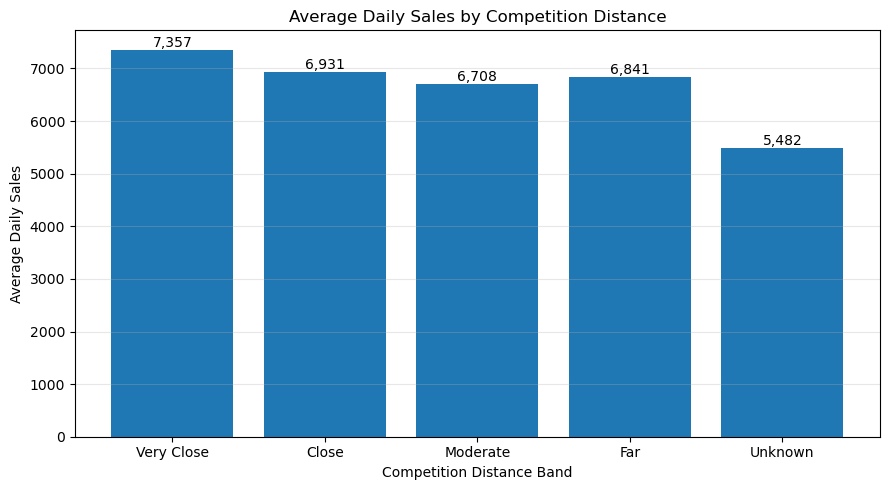

In [150]:
# Plot for average sales by competition distance

competition_order = [
    "Very Close",
    "Close",
    "Moderate",
    "Far",
    "Unknown"
]

competition_plot = (competition_summary.set_index("CompetitionDistanceBand").reindex(competition_order).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(competition_plot["CompetitionDistanceBand"], competition_plot["AverageDailySales"])

ax.set_title("Average Daily Sales by Competition Distance")
ax.set_xlabel("Competition Distance Band")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(competition_plot["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_competition_distance.png", dpi=300, bbox_inches="tight")

plt.show()

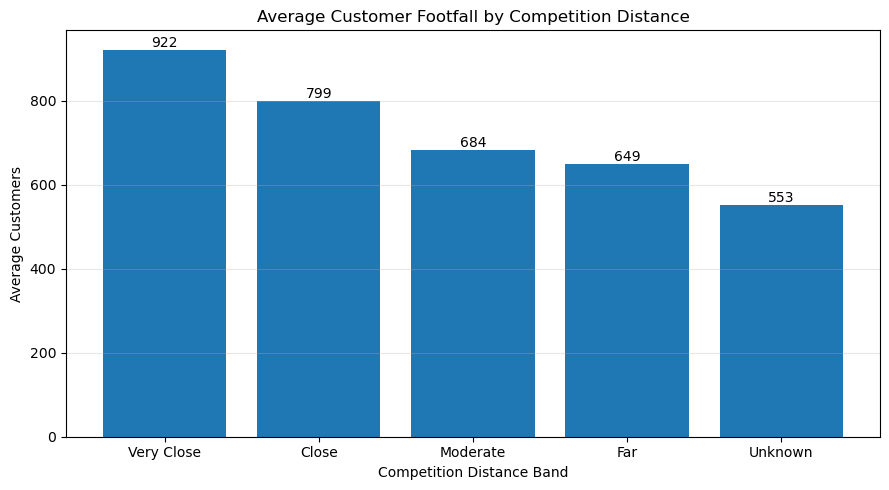

In [151]:
# Plot for customers by competition distance

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(competition_plot["CompetitionDistanceBand"], competition_plot["AverageCustomers"])

ax.set_title("Average Customer Footfall by Competition Distance")
ax.set_xlabel("Competition Distance Band")
ax.set_ylabel("Average Customers")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(competition_plot["AverageCustomers"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_customers_by_competition_distance.png", dpi=300, bbox_inches="tight")

plt.show()

## Holiday Analysis

In [154]:
# State-holiday summary

state_holiday_summary = (open_df
    .groupby("StateHolidayLabel", observed=True)
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

state_holiday_summary

,StateHolidayLabel,OperatingRecords,NumberOfStores,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,Christmas Holiday,71,20,9743.75,8397.0,1569.23,6.27
1,Easter Holiday,145,32,9887.89,8423.0,1686.89,6.32
2,No State Holiday,843428,1115,6953.96,6368.0,762.13,9.50
3,Public Holiday,694,156,8487.47,7556.0,1279.17,7.54


In [155]:
state_holiday_summary.to_csv(TABLE_DIR / "state_holiday_performance.csv", index=False)

In [156]:
# School-holiday summary

school_holiday_summary = (open_df
    .groupby("SchoolHolidayLabel", observed=True)
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

school_holiday_summary

,SchoolHolidayLabel,OperatingRecords,NumberOfStores,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,No School Holiday,680893,1115,6897.21,6326.0,757.88,9.48
1,School Holiday,163445,1115,7200.71,6562.0,783.18,9.55


In [157]:
school_holiday_summary.to_csv(TABLE_DIR / "school_holiday_performance.csv", index=False)

In [158]:
# School-holiday uplift

school_lookup = (school_holiday_summary.set_index("SchoolHolidayLabel"))

normal_sales = school_lookup.loc["No School Holiday", "AverageDailySales"]

holiday_sales = school_lookup.loc["School Holiday", "AverageDailySales"]

normal_customers = school_lookup.loc["No School Holiday", "AverageCustomers"]

holiday_customers = school_lookup.loc["School Holiday", "AverageCustomers"]

school_holiday_uplift = pd.DataFrame({
    "Measure": [
        "Average Sales",
        "Average Customers"
    ],
    "NoSchoolHoliday": [
        normal_sales,
        normal_customers
    ],
    "SchoolHoliday": [
        holiday_sales,
        holiday_customers
    ],
    "DifferencePct": [
        (
            (holiday_sales - normal_sales) /
            normal_sales
        ) * 100,
        (
            (holiday_customers - normal_customers) /
            normal_customers
        ) * 100
    ]
}).round(2)

school_holiday_uplift

,Measure,NoSchoolHoliday,SchoolHoliday,DifferencePct
0,Average Sales,6897.21,7200.71,4.40
1,Average Customers,757.88,783.18,3.34


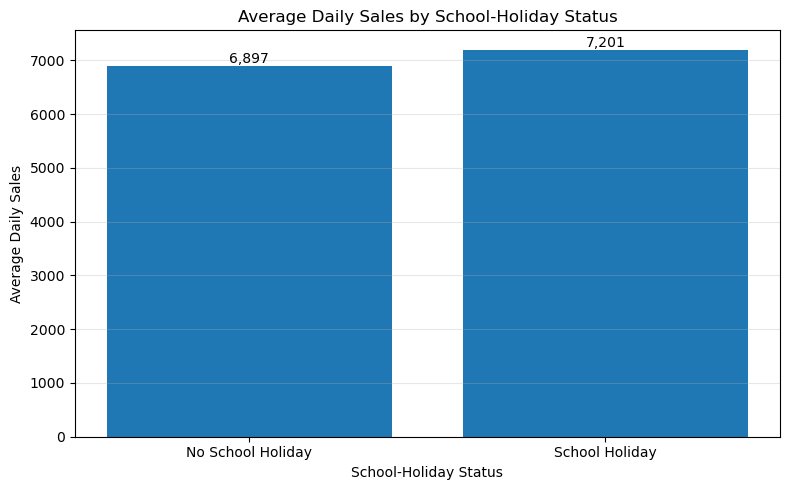

In [159]:
# Plot for school-holiday comparison

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(school_holiday_summary["SchoolHolidayLabel"], school_holiday_summary["AverageDailySales"])

ax.set_title("Average Daily Sales by School-Holiday Status")
ax.set_xlabel("School-Holiday Status")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(school_holiday_summary["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_school_holiday.png", dpi=300, bbox_inches="tight")

plt.show()

In [160]:
# Number of open state-holiday records


state_holiday_summary[
    [
        "StateHolidayLabel",
        "OperatingRecords",
        "NumberOfStores"
    ]
]

,StateHolidayLabel,OperatingRecords,NumberOfStores
0,Christmas Holiday,71,20
1,Easter Holiday,145,32
2,No State Holiday,843428,1115
3,Public Holiday,694,156


### Competition and Holiday Insight

Store performance did not improve as competitor distance increased. Stores with a very close competitor recorded the highest average daily sales at 7,357.07 and the highest customer footfall at 921.53, while stores in the far category recorded lower average sales of 6,840.74 but the highest sales per customer at 10.60. This suggests that stores in more competitive locations may compensate through stronger customer traffic, whereas stores with distant competitors rely more on higher turnover per customer. Holiday conditions also affected performance: school-holiday periods were associated with a modest 4.40% increase in average sales and a 3.34% increase in customer footfall. State-holiday records showed higher average sales and customer counts than normal days, but these results should be treated cautiously because very few stores remained open on Christmas, Easter, and public holidays. Overall, the findings indicate that competitor proximity and holiday conditions are associated with different store-performance patterns, but the relationship is not simply linear and should be considered alongside store type, assortment, and opening status.

####

## Time-Pattern Analysis

In [164]:
# Weekday performance

open_df["Year"] = open_df["Date"].dt.year
open_df["Month"] = open_df["Date"].dt.month
open_df["MonthName"] = open_df["Date"].dt.month_name()
open_df["DayOfWeek"] = open_df["Date"].dt.dayofweek + 1
open_df["DayName"] = open_df["Date"].dt.day_name()

weekday_summary = (open_df
    .groupby(["DayOfWeek", "DayName"], observed=True)
    .agg(
        OperatingRecords=("Sales", "size"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .sort_values("DayOfWeek")
    .round(2)
)

weekday_summary

,DayOfWeek,DayName,OperatingRecords,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,1,Monday,137557,8216.25,7539.0,855.46,9.90
1,2,Tuesday,143955,7088.41,6502.0,770.02,9.59
2,3,Wednesday,141922,6728.79,6210.0,740.67,9.50
3,4,Thursday,134626,6768.21,6246.0,755.67,9.36
4,5,Friday,138633,7073.03,6581.0,781.81,9.44
5,6,Saturday,144052,5875.08,5425.0,660.21,9.26
6,7,Sunday,3593,8224.72,6876.0,1441.53,6.46


In [167]:
weekday_summary.to_csv(TABLE_DIR / "weekday_performance.csv", index=False)

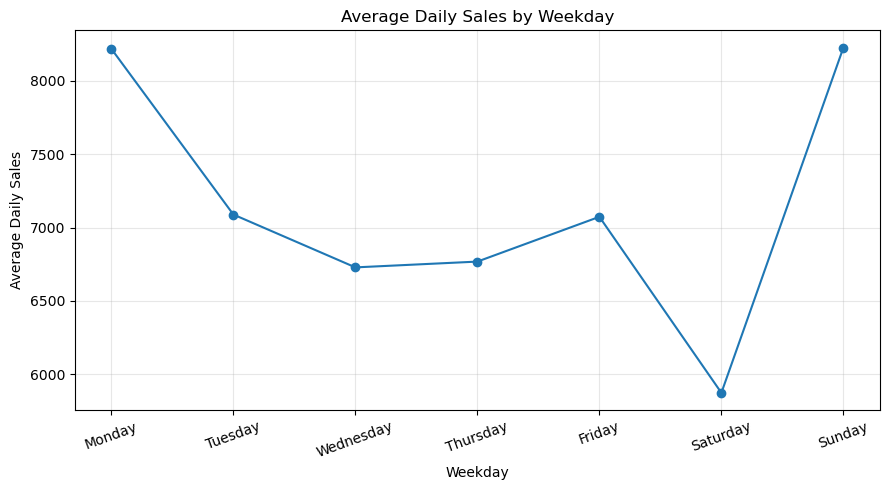

In [168]:
# Plot for average sales by weekday

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    weekday_summary["DayName"],
    weekday_summary["AverageDailySales"],
    marker="o"
)

ax.set_title("Average Daily Sales by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Average Daily Sales")
ax.grid(alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_weekday.png", dpi=300, bbox_inches="tight")

plt.show()

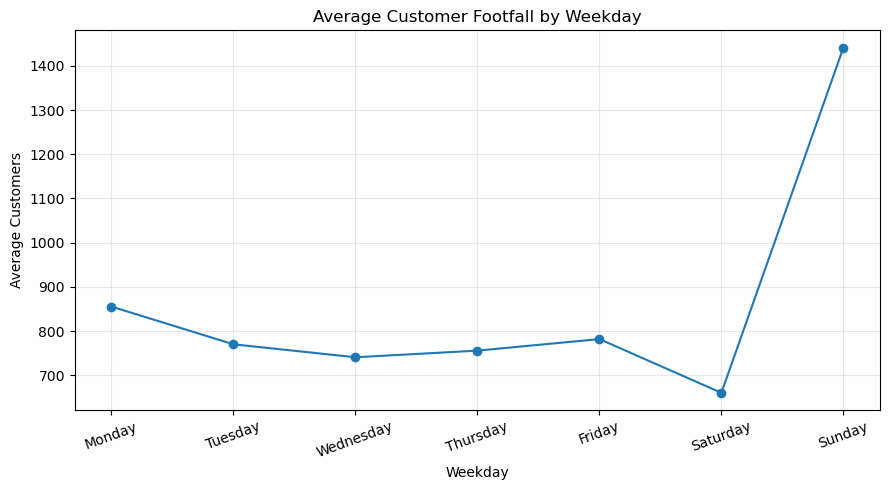

In [172]:
# Plot for customer footfall by weekday

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(weekday_summary["DayName"], weekday_summary["AverageCustomers"], marker="o")

ax.set_title("Average Customer Footfall by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Average Customers")
ax.grid(alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(PLOT_DIR / "average_customers_by_weekday.png", dpi=300, bbox_inches="tight")

plt.show()

In [170]:
# Monthly performance

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_summary = (open_df
    .groupby(["Month", "MonthName"], observed=True)
    .agg(
        OperatingRecords=("Sales", "size"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .sort_values("Month")
    .round(2)
)

monthly_summary

,Month,MonthName,OperatingRecords,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,1,January,86335,6564.30,6062.0,722.58,9.45
1,2,February,80239,6589.49,6079.0,731.54,9.39
2,3,March,85975,6976.82,6385.0,759.13,9.56
3,4,April,81726,7046.66,6431.0,774.32,9.47
4,5,May,80099,7106.81,6592.0,779.33,9.54
5,6,June,82571,7001.40,6365.0,759.32,9.60
6,7,July,85576,6953.58,6407.0,752.84,9.64
7,8,August,54411,6649.23,6124.0,750.41,9.25
8,9,September,52321,6547.47,6000.0,745.74,9.13
9,10,October,53291,6602.97,6105.0,752.59,9.18


In [171]:
monthly_summary.to_csv(TABLE_DIR / "monthly_performance.csv", index=False)

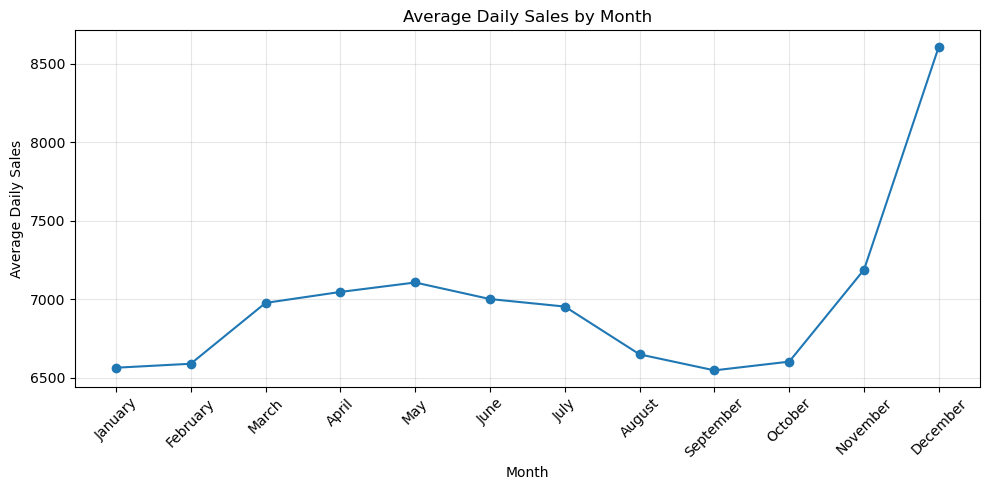

In [173]:
# Plot for average sales by month

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_summary["MonthName"], monthly_summary["AverageDailySales"], marker="o")

ax.set_title("Average Daily Sales by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Daily Sales")
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_month.png", dpi=300, bbox_inches="tight")

plt.show()

In [174]:
# Yearly performance

yearly_summary = (open_df
    .groupby("Year")
    .agg(
        OperatingRecords=("Sales", "size"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

yearly_summary

,Year,OperatingRecords,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,2013,337924,6814.78,6218.0,757.58,9.37
1,2014,310385,7026.13,6428.0,774.81,9.43
2,2015,196029,7088.24,6530.0,752.69,9.81


In [175]:
yearly_summary.to_csv(TABLE_DIR / "yearly_performance.csv", index=False)

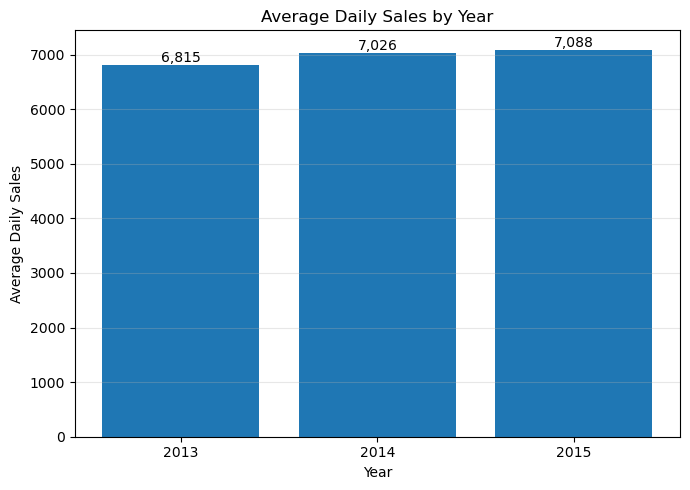

In [176]:
# Plot for average sales by year

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(yearly_summary["Year"].astype(str), yearly_summary["AverageDailySales"])

ax.set_title("Average Daily Sales by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(yearly_summary["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_year.png", dpi=300, bbox_inches="tight")

plt.show()

In [177]:
# Monthly trend across the full period

open_df["YearMonth"] = (open_df["Date"].dt.to_period("M").astype(str))

monthly_trend = (open_df
    .groupby("YearMonth")
    .agg(
        AverageDailySales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

monthly_trend

,YearMonth,AverageDailySales,AverageCustomers,AverageSalesPerCustomer
0,2013-01,6240.51,706.06,9.20
1,2013-02,6428.84,721.25,9.28
2,2013-03,7213.09,787.69,9.52
3,2013-04,6579.79,749.06,9.17
4,2013-05,7077.03,791.02,9.35
5,2013-06,6467.75,732.78,9.25
6,2013-07,6923.61,758.26,9.49
7,2013-08,6596.37,743.24,9.26
8,2013-09,6363.62,727.31,9.12
9,2013-10,6473.35,737.19,9.19


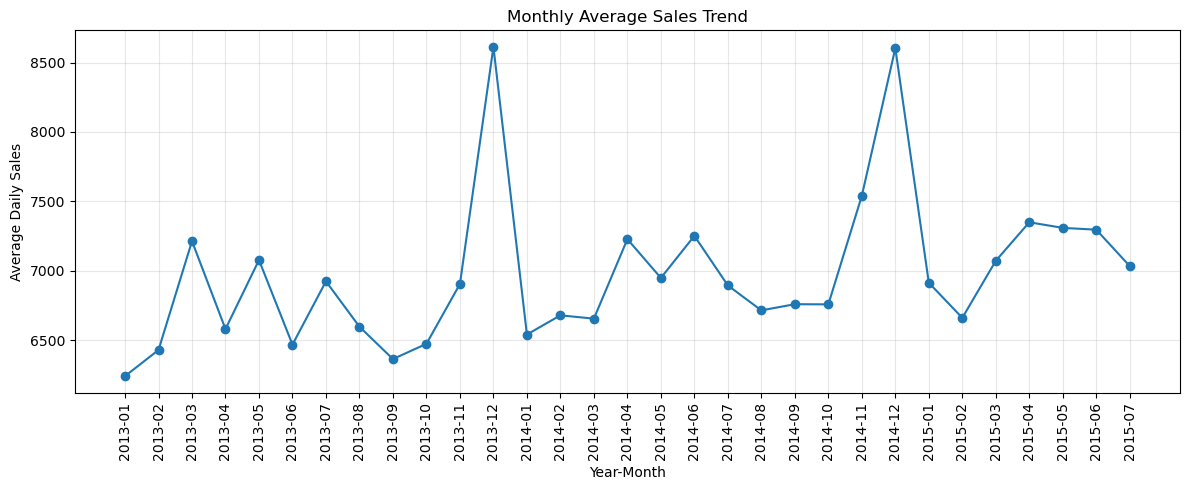

In [178]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_trend["YearMonth"], monthly_trend["AverageDailySales"], marker="o")

ax.set_title("Monthly Average Sales Trend")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Average Daily Sales")
ax.grid(alpha=0.3)

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(PLOT_DIR / "monthly_average_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [179]:
# Weekday and promotion interaction

weekday_promo_summary = (open_df
    .groupby(
        ["DayOfWeek", "DayName", "PromoLabel"],
        observed=True
    )
    .agg(
        AverageSales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .sort_values(["DayOfWeek", "PromoLabel"])
    .round(2)
)

weekday_promo_summary

,DayOfWeek,DayName,PromoLabel,AverageSales,AverageCustomers,AverageSalesPerCustomer
0,1,Monday,No Promotion,6222.73,742.80,8.76
1,1,Monday,Promotion,9772.91,943.44,10.79
2,2,Tuesday,No Promotion,5716.41,687.55,8.75
3,2,Tuesday,Promotion,8277.63,841.50,10.33
4,3,Wednesday,No Promotion,5617.73,672.64,8.80
5,3,Wednesday,Promotion,7685.68,799.27,10.10
6,4,Thursday,No Promotion,5750.88,688.88,8.79
7,4,Thursday,Promotion,7598.79,810.20,9.82
8,5,Friday,No Promotion,6344.41,735.23,9.03
9,5,Friday,Promotion,7744.39,824.73,9.82


In [180]:
weekday_promo_sales = (weekday_promo_summary
    .pivot(
        index=["DayOfWeek", "DayName"],
        columns="PromoLabel",
        values="AverageSales"
    )
    .reset_index()
    .sort_values("DayOfWeek")
)

weekday_promo_sales["SalesUpliftPct"] = ((weekday_promo_sales["Promotion"] - weekday_promo_sales["No Promotion"]) / weekday_promo_sales["No Promotion"]) * 100

weekday_promo_sales = weekday_promo_sales.round(2)

weekday_promo_sales

PromoLabel,DayOfWeek,DayName,No Promotion,Promotion,SalesUpliftPct
0,1,Monday,6222.73,9772.91,57.05
1,2,Tuesday,5716.41,8277.63,44.80
2,3,Wednesday,5617.73,7685.68,36.81
3,4,Thursday,5750.88,7598.79,32.13
4,5,Friday,6344.41,7744.39,22.07
5,6,Saturday,5875.08,NaN,NaN
6,7,Sunday,8224.72,NaN,NaN


In [181]:
monthly_trend.to_csv(TABLE_DIR / "monthly_sales_trend.csv", index=False)

weekday_promo_sales.to_csv(TABLE_DIR / "weekday_promotion_uplift.csv", index=False)

### Time-Pattern Insight

Rossmann store performance followed clear weekly and seasonal patterns. Monday recorded the highest weekday sales among regularly operating days, with average daily sales of 8,216.25, while Saturday recorded the lowest at 5,875.08. Sunday showed similarly high average sales of 8,224.72, but this result should be interpreted cautiously because only 3,593 Sunday operating records were available and the stores that opened on Sundays served unusually high customer volumes. Monthly performance peaked strongly in December, when average daily sales reached 8,608.96, average customer footfall rose to 886.63, and sales per customer reached 10.05, indicating a combined seasonal increase in traffic and customer spending. November also performed strongly, while January, February, August, September, and October recorded comparatively weaker averages. Average sales increased gradually across the observed years, from 6,814.78 in 2013 to 7,088.24 in 2015, although 2015 contains only data up to July and is therefore not directly comparable as a full year. Promotion response also varied by weekday: promotional uplift was strongest on Monday at 57.05% and declined steadily through the working week to 22.07% on Friday. No promotional observations appeared on Saturday or Sunday, so promotional effectiveness cannot be assessed for weekends. Overall, the results suggest that sales planning should account for strong Monday demand, December seasonality, and the greater promotional responsiveness observed earlier in the working week.

## Promo2 Effectiveness Analysis

Promo2 is Rossmann’s continuing promotion programme. Unlike the regular Promo variable, a store may be enrolled in Promo2 but the programme is only active during specific months.

In [182]:
# Promo2 start date

promo2_start = (open_df["Promo2SinceYear"]
    .astype("Int64")
    .astype(str)
    + "-W"
    + open_df["Promo2SinceWeek"]
    .astype("Int64")
    .astype(str)
    .str.zfill(2)
    + "-1"
)

open_df["Promo2StartDate"] = pd.to_datetime(
    promo2_start,
    format="%G-W%V-%u",
    errors="coerce"
)

Here, -1 represents Monday of the relevant ISO week.

In [183]:
# Month abbreviation

open_df["MonthAbbreviation"] = (open_df["Date"].dt.strftime("%b"))

In [184]:
# Identifying whether Promo2 was active

open_df["Promo2Active"] = (
    (open_df["Promo2"] == 1)
    &
    (open_df["Date"] >= open_df["Promo2StartDate"])
    &
    open_df.apply(
        lambda row: (
            row["MonthAbbreviation"]
            in str(row["PromoInterval"]).split(",")
        ),
        axis=1
    )
).astype(int)

In [185]:
open_df["Promo2ActiveLabel"] = (
    open_df["Promo2Active"]
    .map({
        0: "Promo2 Inactive",
        1: "Promo2 Active"
    })
)

In [186]:
open_df["Promo2ActiveLabel"].value_counts()

Promo2ActiveLabel
Promo2 Inactive    722331
Promo2 Active      122007
Name: count, dtype: int64

In [187]:
# Overall active Promo2 comparison

promo2_summary = (open_df
    .groupby("Promo2ActiveLabel")
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

promo2_summary

,Promo2ActiveLabel,OperatingRecords,NumberOfStores,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,Promo2 Active,122007,571,6497.46,6052.0,673.61,10.03
1,Promo2 Inactive,722331,1115,7033.40,6426.0,777.84,9.40


In [188]:
# The difference

promo2_lookup = (promo2_summary.set_index("Promo2ActiveLabel"))

inactive_sales = promo2_lookup.loc["Promo2 Inactive", "AverageDailySales"]

active_sales = promo2_lookup.loc["Promo2 Active", "AverageDailySales"]

inactive_customers = promo2_lookup.loc["Promo2 Inactive", "AverageCustomers"]

active_customers = promo2_lookup.loc["Promo2 Active", "AverageCustomers"]

inactive_spc = promo2_lookup.loc["Promo2 Inactive", "AverageSalesPerCustomer"]

active_spc = promo2_lookup.loc["Promo2 Active", "AverageSalesPerCustomer"]

promo2_uplift = pd.DataFrame({
    "Measure": [
        "Average Sales",
        "Average Customers",
        "Average Sales per Customer"
    ],
    "Promo2Inactive": [
        inactive_sales,
        inactive_customers,
        inactive_spc
    ],
    "Promo2Active": [
        active_sales,
        active_customers,
        active_spc
    ],
    "DifferencePct": [
        ((active_sales - inactive_sales) / inactive_sales) * 100,
        ((active_customers - inactive_customers) / inactive_customers) * 100,
        ((active_spc - inactive_spc) / inactive_spc) * 100
    ]
}).round(2)

promo2_uplift

,Measure,Promo2Inactive,Promo2Active,DifferencePct
0,Average Sales,7033.40,6497.46,-7.62
1,Average Customers,777.84,673.61,-13.40
2,Average Sales per Customer,9.40,10.03,6.70


In [190]:
# Only the stores enrolled in Promo2

# The overall comparison includes stores that never participated in Promo2. 
# A better comparison is to examine only stores where Promo2 == 1.

promo2_stores_df = open_df[open_df["Promo2"] == 1].copy()

promo2_enrolled_summary = (promo2_stores_df
    .groupby("Promo2ActiveLabel")
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        MedianDailySales=("Sales", "median"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .round(2)
)

promo2_enrolled_summary

,Promo2ActiveLabel,OperatingRecords,NumberOfStores,AverageDailySales,MedianDailySales,AverageCustomers,AverageSalesPerCustomer
0,Promo2 Active,122007,571,6497.46,6052.0,673.61,10.03
1,Promo2 Inactive,299039,571,6584.10,6084.0,684.63,9.95


In [191]:
# uplift with enrolled stores

enrolled_lookup = (promo2_enrolled_summary.set_index("Promo2ActiveLabel"))

promo2_enrolled_uplift = pd.DataFrame({
    "Measure": [
        "Average Sales",
        "Average Customers",
        "Average Sales per Customer"
    ],
    "InactiveValue": [
        enrolled_lookup.loc[
            "Promo2 Inactive",
            "AverageDailySales"
        ],
        enrolled_lookup.loc[
            "Promo2 Inactive",
            "AverageCustomers"
        ],
        enrolled_lookup.loc[
            "Promo2 Inactive",
            "AverageSalesPerCustomer"
        ]
    ],
    "ActiveValue": [
        enrolled_lookup.loc[
            "Promo2 Active",
            "AverageDailySales"
        ],
        enrolled_lookup.loc[
            "Promo2 Active",
            "AverageCustomers"
        ],
        enrolled_lookup.loc[
            "Promo2 Active",
            "AverageSalesPerCustomer"
        ]
    ]
})

promo2_enrolled_uplift["DifferencePct"] = ((promo2_enrolled_uplift["ActiveValue"] - promo2_enrolled_uplift["InactiveValue"]) / promo2_enrolled_uplift["InactiveValue"]) * 100

promo2_enrolled_uplift = (promo2_enrolled_uplift.round(2))

promo2_enrolled_uplift

,Measure,InactiveValue,ActiveValue,DifferencePct
0,Average Sales,6584.10,6497.46,-1.32
1,Average Customers,684.63,673.61,-1.61
2,Average Sales per Customer,9.95,10.03,0.80


In [192]:
# Interaction between regular Promo and Promo2

open_df["PromotionCombination"] = np.select(
    [
        (open_df["Promo"] == 0) &
        (open_df["Promo2Active"] == 0),

        (open_df["Promo"] == 1) &
        (open_df["Promo2Active"] == 0),

        (open_df["Promo"] == 0) &
        (open_df["Promo2Active"] == 1),

        (open_df["Promo"] == 1) &
        (open_df["Promo2Active"] == 1)
    ],
    [
        "No Active Promotion",
        "Regular Promo Only",
        "Promo2 Only",
        "Regular Promo and Promo2"
    ],
    default="Unknown"
)

In [193]:
promotion_combination_summary = (open_df
    .groupby("PromotionCombination")
    .agg(
        OperatingRecords=("Sales", "size"),
        NumberOfStores=("Store", "nunique"),
        AverageDailySales=("Sales", "mean"),
        AverageCustomers=("Customers", "mean"),
        AverageSalesPerCustomer=("SalesPerCustomer", "mean")
    )
    .reset_index()
    .sort_values(
        "AverageDailySales",
        ascending=False
    )
    .round(2)
)

promotion_combination_summary

,PromotionCombination,OperatingRecords,NumberOfStores,AverageDailySales,AverageCustomers,AverageSalesPerCustomer
2,Regular Promo Only,321594,1115,8307.51,860.66,10.07
3,Regular Promo and Promo2,55281,571,7770.48,750.34,10.82
0,No Active Promotion,400737,1115,6010.92,711.37,8.87
1,Promo2 Only,66726,571,5442.78,610.04,9.37


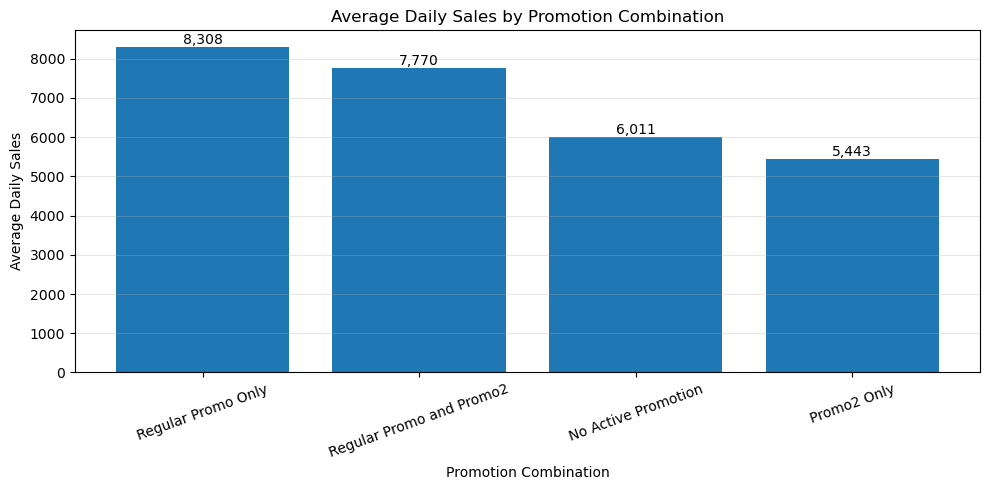

In [194]:
# Plotting the promotion combinations

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(promotion_combination_summary["PromotionCombination"], promotion_combination_summary["AverageDailySales"])

ax.set_title(
    "Average Daily Sales by Promotion Combination"
)
ax.set_xlabel("Promotion Combination")
ax.set_ylabel("Average Daily Sales")
ax.grid(axis="y", alpha=0.3)

for i, value in enumerate(promotion_combination_summary["AverageDailySales"]):
    ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(PLOT_DIR / "average_sales_by_promotion_combination.png", dpi=300, bbox_inches="tight")

plt.show()

In [195]:
promo2_summary.to_csv(TABLE_DIR / "promo2_overall_summary.csv", index=False)

promo2_uplift.to_csv(TABLE_DIR / "promo2_overall_uplift.csv", index=False)

promo2_enrolled_summary.to_csv(TABLE_DIR / "promo2_enrolled_store_summary.csv", index=False)

promo2_enrolled_uplift.to_csv(TABLE_DIR / "promo2_enrolled_store_uplift.csv", index=False)

promotion_combination_summary.to_csv(TABLE_DIR / "promotion_combination_summary.csv", index=False)

### Promo2 Effectiveness Insight

Promo2 was not associated with improved overall store performance. Among stores enrolled in Promo2, active periods recorded 1.32% lower average sales and 1.61% lower customer footfall than inactive periods, although average sales per customer increased slightly by 0.80%. The promotion-combination analysis also showed that Regular Promo Only produced the highest average daily sales at 8,307.51, while Promo2 Only produced the lowest at 5,442.78. When both programmes were active, average sales reached 7,770.48, which was higher than periods with no active promotion but lower than regular promotion alone. Overall, the findings suggest that the short-term regular promotion was more strongly associated with sales growth than Promo2, while Promo2 may have supported slightly higher spending per customer without generating additional traffic or total sales.

## Final Store Strategy Framework

In [196]:
# Merging store performance with promotion response

store_strategy = (store_performance
    .merge(
        store_sales_promo_pivot[
            [
                "Store",
                "AverageNonPromoSales",
                "AveragePromoSales",
                "SalesUpliftPct",
                "PromotionResponseSegment"
            ]
        ],
        on="Store",
        how="left"
    )
)

In [197]:
store_strategy.head()

,Store,OperatingDays,TotalSales,AverageDailySales,MedianDailySales,SalesStandardDeviation,AverageCustomers,MedianCustomers,AverageSalesPerCustomer,PromoDays,...,StoreTypeLabel,AssortmentLabel,AverageSalesRank,CustomerRank,SalesPerCustomerRank,PerformanceSegment,AverageNonPromoSales,AveragePromoSales,SalesUpliftPct,PromotionResponseSegment
0,1,781,3716854,4759.10,4647.0,1012.11,564.05,550.0,8.39,350,...,Type C,Basic,961,784,756,Low Sales / Low Footfall,4319.76,5300.11,22.69,Low Promotion Response
1,2,784,3883858,4953.90,4783.0,1610.15,584.00,575.5,8.41,354,...,Type A,Basic,915,744,754,Low Sales / Low Footfall,3864.29,6277.44,62.45,High Promotion Response
2,3,779,5408261,6942.57,6619.0,2193.38,750.08,744.0,9.12,350,...,Type A,Basic,487,421,617,High Sales / High Footfall,5382.61,8854.63,64.50,High Promotion Response
3,4,784,7556507,9638.40,9430.5,1936.03,1321.75,1301.5,7.25,353,...,Type C,Extended,115,58,1003,High Sales / High Footfall,8870.35,10576.16,19.23,Low Promotion Response
4,5,779,3642818,4676.27,4616.0,1765.75,537.34,564.0,8.61,351,...,Type A,Basic,976,844,716,Low Sales / Low Footfall,3511.41,6096.68,73.63,High Promotion Response


In [198]:
# Creating strategic store categories

conditions = [
    (
        store_strategy["PerformanceSegment"]
        == "High Sales / High Footfall"
    )
    &
    (
        store_strategy["PromotionResponseSegment"]
        == "High Promotion Response"
    ),

    (
        store_strategy["PerformanceSegment"]
        == "High Sales / High Footfall"
    ),

    (
        store_strategy["PerformanceSegment"]
        == "High Sales / Low Footfall"
    ),

    (
        store_strategy["PerformanceSegment"]
        == "Low Sales / High Footfall"
    ),

    (
        store_strategy["PerformanceSegment"]
        == "Low Sales / Low Footfall"
    )
]

labels = ["High-Value Promotion Priority", "Strong Core Performer", "High Customer Value Store", "Conversion Improvement Priority", "Turnaround Priority"]

store_strategy["StrategicCategory"] = np.select(conditions, labels, default="Review Individually")

In [199]:
strategy_summary = (store_strategy
    .groupby("StrategicCategory")
    .agg(
        NumberOfStores=("Store", "count"),
        AverageDailySales=("AverageDailySales", "mean"),
        AverageCustomers=("AverageCustomers", "mean"),
        AverageSalesPerCustomer=(
            "AverageSalesPerCustomer",
            "mean"
        ),
        AveragePromotionUplift=("SalesUpliftPct", "mean"),
        AverageSalesVariability=(
            "SalesCoefficientOfVariationPct",
            "mean"
        )
    )
    .reset_index()
    .round(2)
)

strategy_summary

,StrategicCategory,NumberOfStores,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,AveragePromotionUplift,AverageSalesVariability
0,Conversion Improvement Priority,107,5896.34,784.57,7.55,42.14,27.96
1,High Customer Value Store,107,7354.76,595.40,12.31,39.07,26.71
2,High-Value Promotion Priority,87,8753.49,945.94,9.44,62.82,33.05
3,Strong Core Performer,364,8978.96,1038.24,9.00,32.43,24.12
4,Turnaround Priority,450,5076.34,518.82,9.83,44.97,28.39


In [200]:
recommendation_map = {
    "High-Value Promotion Priority":
        "Prioritise for regular promotions because these stores combine strong baseline performance with high promotional responsiveness.",

    "Strong Core Performer":
        "Maintain current operations and use promotions selectively to protect profitability and avoid unnecessary discounting.",

    "High Customer Value Store":
        "Protect high spending per customer and focus on targeted footfall-building campaigns.",

    "Conversion Improvement Priority":
        "Review assortment, cross-selling and promotion design because customer traffic is relatively high but sales per customer are weak.",

    "Turnaround Priority":
        "Conduct store-specific review of local demand, competition, assortment and promotion response before allocating further promotional resources.",

    "Review Individually":
        "Assess store-specific performance and promotional history before determining the appropriate intervention."
}

store_strategy["RecommendedAction"] = (store_strategy["StrategicCategory"].map(recommendation_map))

In [201]:
# Identifying the priority stores

# Promotion-priority stores

promotion_priority_stores = (store_strategy[store_strategy["StrategicCategory"] == "High-Value Promotion Priority"].sort_values("SalesUpliftPct", ascending=False))

promotion_priority_stores[
    [
        "Store",
        "StoreTypeLabel",
        "AssortmentLabel",
        "AverageDailySales",
        "AverageCustomers",
        "SalesUpliftPct",
        "SalesCoefficientOfVariationPct"
    ]
].head(15)

,Store,StoreTypeLabel,AssortmentLabel,AverageDailySales,AverageCustomers,SalesUpliftPct,SalesCoefficientOfVariationPct
270,271,Type A,Basic,7841.69,791.86,97.09,43.87
551,552,Type A,Basic,7721.87,689.90,95.21,40.35
897,898,Type A,Basic,6615.43,710.92,91.27,43.45
155,156,Type A,Basic,6961.61,712.62,87.20,40.44
260,261,Type D,Extended,12616.49,948.93,86.62,38.62
875,876,Type A,Basic,9228.91,1016.98,84.61,44.21
962,963,Type A,Extended,10764.32,1016.21,83.14,41.87
744,745,Type A,Basic,7499.08,709.63,82.91,39.62
374,375,Type A,Extended,9164.38,758.98,81.97,39.75
778,779,Type A,Basic,7128.52,700.08,79.47,40.60


In [202]:
# Turnaround-priority stores

turnaround_priority_stores = (store_strategy[store_strategy["StrategicCategory"] == "Turnaround Priority"].sort_values("AverageDailySales"))

turnaround_priority_stores[
    [
        "Store",
        "StoreTypeLabel",
        "AssortmentLabel",
        "AverageDailySales",
        "AverageCustomers",
        "AverageSalesPerCustomer",
        "SalesUpliftPct"
    ]
].head(15)

,Store,StoreTypeLabel,AssortmentLabel,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,SalesUpliftPct
306,307,Type A,Basic,2703.74,307.81,8.64,79.21
542,543,Type C,Basic,2790.38,240.18,11.23,110.16
197,198,Type A,Basic,2900.60,338.48,8.23,144.93
207,208,Type C,Basic,2936.29,413.47,7.05,26.27
840,841,Type A,Basic,2972.61,412.17,7.13,69.73
253,254,Type D,Basic,3005.98,258.67,11.49,31.07
793,794,Type C,Extended,3083.81,521.83,5.89,9.81
218,219,Type A,Basic,3133.71,406.44,7.67,42.74
209,210,Type D,Basic,3193.98,326.26,9.68,45.70
424,425,Type D,Extended,3237.66,434.38,7.39,43.89


In [203]:
# Conversion-improvement stores

conversion_priority_stores = (store_strategy[store_strategy["StrategicCategory"]  == "Conversion Improvement Priority"].sort_values("AverageSalesPerCustomer"))

conversion_priority_stores[
    [
        "Store",
        "StoreTypeLabel",
        "AssortmentLabel",
        "AverageDailySales",
        "AverageCustomers",
        "AverageSalesPerCustomer",
        "SalesUpliftPct"
    ]
].head(15)

,Store,StoreTypeLabel,AssortmentLabel,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,SalesUpliftPct
352,353,Type B,Extra,5651.37,1451.09,3.86,4.31
273,274,Type B,Extra,4070.83,992.74,4.04,-6.95
511,512,Type B,Extra,5510.98,1287.97,4.27,10.50
810,811,Type A,Basic,4132.04,682.77,6.02,21.99
418,419,Type C,Basic,5311.16,852.06,6.17,38.89
1080,1081,Type B,Basic,5924.92,937.18,6.24,61.36
462,463,Type A,Basic,6094.67,969.43,6.25,51.20
529,530,Type A,Extended,4634.32,750.81,6.39,13.84
595,596,Type C,Basic,4505.82,698.39,6.42,26.29
377,378,Type A,Extended,6324.80,970.16,6.47,26.51


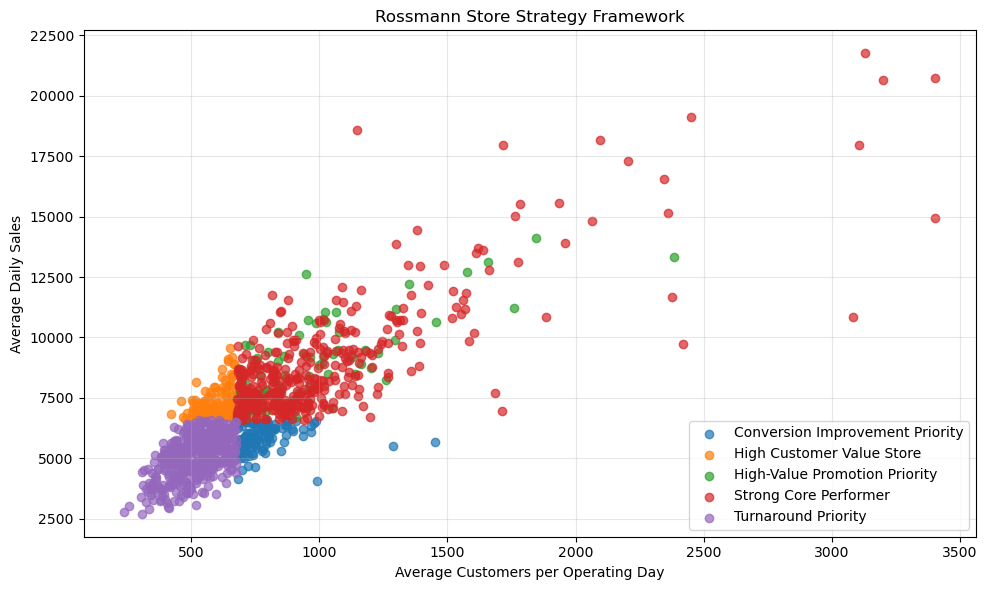

In [204]:
# Plotting the strategic categories

fig, ax = plt.subplots(figsize=(10, 6))

for category, group in store_strategy.groupby("StrategicCategory"):
    ax.scatter(
        group["AverageCustomers"],
        group["AverageDailySales"],
        label=category,
        alpha=0.7
    )

ax.set_title("Rossmann Store Strategy Framework")
ax.set_xlabel("Average Customers per Operating Day")
ax.set_ylabel("Average Daily Sales")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(PLOT_DIR / "store_strategy_framework.png", dpi=300, bbox_inches="tight")

plt.show()

In [205]:
store_strategy.to_csv(TABLE_DIR / "final_store_strategy.csv", index=False)

strategy_summary.to_csv(TABLE_DIR / "store_strategy_summary.csv", index=False)

promotion_priority_stores.to_csv(TABLE_DIR / "promotion_priority_stores.csv", index=False)

turnaround_priority_stores.to_csv(TABLE_DIR / "turnaround_priority_stores.csv", index=False)

conversion_priority_stores.to_csv(TABLE_DIR / "conversion_improvement_stores.csv", index=False)

In [206]:
promotion_priority_stores[
    [
        "Store",
        "AverageDailySales",
        "AverageCustomers",
        "SalesUpliftPct"
    ]
].head(10)

,Store,AverageDailySales,AverageCustomers,SalesUpliftPct
270,271,7841.69,791.86,97.09
551,552,7721.87,689.90,95.21
897,898,6615.43,710.92,91.27
155,156,6961.61,712.62,87.20
260,261,12616.49,948.93,86.62
875,876,9228.91,1016.98,84.61
962,963,10764.32,1016.21,83.14
744,745,7499.08,709.63,82.91
374,375,9164.38,758.98,81.97
778,779,7128.52,700.08,79.47


In [207]:
turnaround_priority_stores[
    [
        "Store",
        "AverageDailySales",
        "AverageCustomers",
        "AverageSalesPerCustomer",
        "SalesUpliftPct"
    ]
].head(10)

,Store,AverageDailySales,AverageCustomers,AverageSalesPerCustomer,SalesUpliftPct
306,307,2703.74,307.81,8.64,79.21
542,543,2790.38,240.18,11.23,110.16
197,198,2900.60,338.48,8.23,144.93
207,208,2936.29,413.47,7.05,26.27
840,841,2972.61,412.17,7.13,69.73
253,254,3005.98,258.67,11.49,31.07
793,794,3083.81,521.83,5.89,9.81
218,219,3133.71,406.44,7.67,42.74
209,210,3193.98,326.26,9.68,45.70
424,425,3237.66,434.38,7.39,43.89


### Store Strategy Insight

The final strategy framework shows that Rossmann stores require different interventions based on both baseline performance and promotional responsiveness. The largest group was the Turnaround Priority segment, containing 450 stores with the lowest average daily sales at 5,076.34 and the lowest average customer footfall at 518.82. However, these stores still recorded an average promotional uplift of 44.97%, indicating that promotions may temporarily improve performance even where underlying demand is weak. They should therefore receive store-specific reviews covering local competition, assortment, customer traffic, and promotion sustainability rather than being treated as uniformly poor promotion candidates. The Strong Core Performer segment contained 364 stores and achieved the highest average daily sales at 8,978.96 and highest customer footfall at 1,038.24, but a lower average promotional uplift of 32.43%, suggesting that these stores rely more on strong normal-day performance and may only require selective promotion. A smaller group of 87 High-Value Promotion Priority stores combined strong sales of 8,753.49 with a high average uplift of 62.82%, making them the clearest candidates for targeted regular promotions. The Conversion Improvement Priority stores attracted relatively high footfall but generated the lowest sales per customer at 7.55, while High Customer Value stores achieved the highest sales per customer at 12.31 despite lower footfall. Overall, the framework suggests that Rossmann should allocate promotional resources selectively, protect strong core stores, improve customer spending in high-footfall underperformers, build traffic in high-value stores, and investigate the structural causes of weak baseline performance in turnaround stores.

In [208]:
print("Number of rows in open_df:", len(open_df))
print("Number of unique stores:", open_df["Store"].nunique())
print("Date range:", open_df["Date"].min(), "to", open_df["Date"].max())
print("Missing values in key columns:")
print(
    open_df[
        [
            "Sales",
            "Customers",
            "StoreTypeLabel",
            "AssortmentLabel",
            "CompetitionDistanceBand",
            "Promo",
            "Promo2Active"
        ]
    ].isna().sum()
)

Number of rows in open_df: 844338
Number of unique stores: 1115
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Missing values in key columns:
Sales                      0
Customers                  0
StoreTypeLabel             0
AssortmentLabel            0
CompetitionDistanceBand    0
Promo                      0
Promo2Active               0
dtype: int64


In [209]:
from pathlib import Path

table_files = sorted(Path(TABLE_DIR).glob("*.csv"))
plot_files = sorted(Path(PLOT_DIR).glob("*.png"))

print("Number of table files:", len(table_files))
print("Number of plot files:", len(plot_files))

print("\nTables:")
for file in table_files:
    print(file.name)

print("\nPlots:")
for file in plot_files:
    print(file.name)

Number of table files: 43
Number of plot files: 27

Tables:
assortment_performance.csv
assortment_store_level_summary.csv
bottom_10_stores_by_average_sales.csv
competition_distance_band_definitions.csv
competition_distance_band_store_counts.csv
competition_distance_performance.csv
conversion_improvement_stores.csv
data_issue_summary.csv
dataset_summary.csv
descriptive_statistics.csv
final_store_strategy.csv
individual_store_performance.csv
monthly_performance.csv
monthly_sales_trend.csv
overall_dataset_summary.csv
overall_promotion_summary.csv
overall_promotion_uplift.csv
promo2_enrolled_store_summary.csv
promo2_enrolled_store_uplift.csv
promo2_overall_summary.csv
promo2_overall_uplift.csv
promotion_combination_summary.csv
promotion_customer_uplift_by_assortment.csv
promotion_customer_uplift_by_store_type.csv
promotion_priority_stores.csv
promotion_response_segments.csv
promotion_sales_uplift_by_assortment.csv
promotion_sales_uplift_by_store_type.csv
promotion_spc_uplift_by_store_type.